# Lakehouse sísmico de Lima — Bronze y Silver

**Proyecto:** Predicción del daño sísmico por edificio en Lima según la onda, el tipo de suelo y la resonancia, con tecnologías Big Data.

Este notebook lleva las fuentes de `raw/` (descargadas con `descarga.ipynb`) hasta la capa **silver** del lakehouse, con **PySpark + Delta Lake**:

```
raw ──► BRONZE (Delta) ──► SILVER (Delta)
```

| Parte | Contenido | Tablas |
|---|---|---|
| 0 | Configuración de Spark + Delta (Windows) y funciones comunes | — |
| 1 | **Bronze**: ingesta de las 11 fuentes tal como llegaron | 14 tablas en `lakehouse/bronze/` |
| 2 | **Silver ondas**: espectros de respuesta de los acelerogramas CISMID | `ondas_registros`, `espectros`, `eventos` |
| 3 | **Silver territorio**: distritos, suelo E.030, microzonificación y edificios | `distritos`, `e030_parametros`, `suelo`, `microzonificacion_*`, `edificios` |
| 4 | **Silver validación**: Turquía (xBD, Maxar, ShakeMap) y STEAD | `xbd_escenas`, `maxar_pares`, `shakemap_turquia`, `stead_trazas` |
| — | Control de calidad en todas las partes | `calidad_log` |

**Requisitos:** Java 17, `HADOOP_HOME` con `winutils.exe`/`hadoop.dll`, y `pip install pyspark delta-spark geopandas rasterio h3 h5py pypdf pyproj scipy`.

## Parte 0 · Configuración

In [1]:
import os
import sys
from datetime import datetime
from pathlib import Path

RAIZ = Path.cwd()          # el notebook está en la raíz del proyecto (junto a raw/)
RAW = RAIZ / "raw"
LAKE = RAIZ / "lakehouse"

# Área de estudio
PROVINCIAS_ESTUDIO = ["LIMA", "CALLAO"]       # columna NOMBPROV de los límites INEI
ZONA_E030_LIMA = 4                             # Lima y Callao: Zona 4 (Z = 0.45 g)
EPSG_UTM_LIMA = 32718                          # UTM 18S


def ruta(capa, tabla):
    """Ruta (estilo posix) de una tabla Delta: ruta('bronze', 'cismid_registros')."""
    return (LAKE / capa / tabla).as_posix()


def ruta_raw(*partes):
    return RAW.joinpath(*partes).as_posix()


def _jars_delta():
    """JAR de Delta ya descargados por Ivy que no vienen con PySpark (se omiten duplicados como hadoop o parquet)."""
    import pyspark
    ivy = Path.home() / ".ivy2.5.2" / "jars"
    if not ivy.exists() or not list(ivy.glob("io.delta_delta-spark_*.jar")):
        return []
    base = lambda nombre: nombre.rsplit("-", 1)[0].split("_", 1)[-1]          # "org_artifact-1.2.jar" -> "artifact"
    incluidos = {base(j.name) for j in (Path(pyspark.__file__).parent / "jars").glob("*.jar")}
    return sorted(j.as_posix() for j in ivy.glob("*.jar") if base(j.name) not in incluidos)


def crear_spark(nombre="lakehouse", nucleos=4, memoria="4g"):
    """SparkSession local con Delta Lake.

    En Windows, Hadoop necesita hadoop.dll/winutils.exe (HADOOP_HOME). La ruta de la DLL se pasa a la JVM
    con barras "/" porque Spark elimina las "\\" de spark.driver.extraJavaOptions.
    """
    os.environ["PYSPARK_PYTHON"] = sys.executable
    os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
    hadoop_bin = Path(os.environ["HADOOP_HOME"]) / "bin"
    os.environ["PATH"] = str(hadoop_bin) + os.pathsep + os.environ["PATH"]

    from pyspark.sql import SparkSession

    tmp = RAIZ / "tmp_spark"
    tmp.mkdir(exist_ok=True)
    builder = (
        SparkSession.builder.appName(nombre).master(f"local[{nucleos}]")
        .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension")
        .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog")
        .config("spark.driver.memory", memoria)
        .config("spark.driver.host", "127.0.0.1")           # evita resolver el nombre del equipo (cuelga el arranque en Windows)
        .config("spark.driver.bindAddress", "127.0.0.1")
        # Spark 4.2 local: si el primer heartbeat (10 s) llega antes de que termine de inicializarse el
        # BlockManager (~25 s en Windows), puede quedar colgado con NullPointerException en BlockManagerId.
        .config("spark.executor.heartbeatInterval", "60s")
        .config("spark.network.timeout", "600s")
        .config("spark.driver.maxResultSize", "2g")
        .config("spark.driver.extraJavaOptions", f"-Djava.library.path={hadoop_bin.as_posix()}")
        .config("spark.local.dir", str(tmp))          # ruta nativa: "C:/..." se interpreta como URI y rompe el BlockManager
        .config("spark.sql.shuffle.partitions", "16")
        .config("spark.sql.execution.arrow.pyspark.enabled", "true")
        .config("spark.sql.execution.arrow.maxRecordsPerBatch", "20000")
        .config("spark.sql.session.timeZone", "America/Lima")
        .config("spark.ui.showConsoleProgress", "false")
        .config("spark.ui.enabled", "false")                 # sin servidor web: arranque más rápido y estable
    )
    jars = _jars_delta()
    if jars:
        # Los JAR de Delta van directo al classpath del driver (en modo local el ejecutor es la misma JVM).
        # Con spark.jars.packages el ejecutor los "descarga" del propio driver y en Windows esa copia
        # interna a veces se cuelga para siempre (Executor.updateDependencies -> FileDownloadChannel.read).
        builder = builder.config("spark.driver.extraClassPath", ";".join(jars))
        spark = builder.getOrCreate()
    else:
        from delta import configure_spark_with_delta_pip       # primera vez: Ivy descarga los JAR de Delta
        spark = configure_spark_with_delta_pip(builder).getOrCreate()
    spark.sparkContext.setLogLevel("ERROR")
    print(f"Spark {spark.version} | {nucleos} núcleos | lakehouse en {LAKE.as_posix()}")
    return spark


def con_metadatos(df, fuente, archivo=None):
    """Agrega las columnas de linaje de bronze: _fuente, _archivo y _fecha_ingesta.

    archivo=None usa la ruta real de cada fila (_metadata.file_path, solo en lecturas de archivos con Spark);
    si el DataFrame se armó en pandas, pasar el nombre del archivo de origen.
    """
    from pyspark.sql import functions as F
    col_archivo = F.col("_metadata.file_path") if archivo is None else F.lit(str(archivo))
    return (df.withColumn("_fuente", F.lit(fuente))
              .withColumn("_archivo", col_archivo)
              .withColumn("_fecha_ingesta", F.current_timestamp()))


def escribir_delta(df, capa, tabla, particion=None, modo="overwrite"):
    """Escribe (sobrescribe) una tabla Delta y devuelve cuántas filas tiene."""
    w = df.write.format("delta").mode(modo).option("overwriteSchema", "true")
    if particion:
        w = w.partitionBy(particion)
    w.save(ruta(capa, tabla))
    n = df.sparkSession.read.format("delta").load(ruta(capa, tabla)).count()
    print(f"  ✓ {capa}.{tabla}: {n:,} filas")
    return n


def leer(spark, capa, tabla):
    return spark.read.format("delta").load(ruta(capa, tabla))


# ---------------- calidad_log ----------------
# Cada fila descartada, imputada o con advertencia queda registrada. Para descartes masivos que no son
# errores (p. ej. edificios fuera de Lima) se guarda una fila agregada con n_filas.
ESQUEMA_CALIDAD = ("fuente string, tabla string, regla string, accion string, "
                   "registro_id string, detalle string, n_filas long, fecha timestamp")


def registrar_calidad(spark, df_problemas, tabla):
    """Reemplaza en silver.calidad_log las filas de `tabla` por df_problemas (para que re-ejecutar no duplique).

    df_problemas debe tener: fuente, regla, accion, registro_id, detalle, n_filas.
    """
    from pyspark.sql import functions as F
    df = (df_problemas
          .withColumn("tabla", F.lit(tabla))
          .withColumn("fecha", F.current_timestamp())
          .select("fuente", "tabla", "regla", "accion", "registro_id", "detalle",
                  F.col("n_filas").cast("long").alias("n_filas"), "fecha"))
    destino = ruta("silver", "calidad_log")
    if (LAKE / "silver" / "calidad_log" / "_delta_log").exists():
        (df.write.format("delta").mode("overwrite")
           .option("replaceWhere", f"tabla = '{tabla}'").save(destino))
    else:
        df.write.format("delta").mode("overwrite").partitionBy("tabla").save(destino)
    resumen = (df.groupBy("regla", "accion").agg(F.sum("n_filas").alias("filas"))
                 .orderBy(F.desc("filas")).collect())
    for r in resumen:
        print(f"  calidad_log [{tabla}] {r['accion']:<11} {r['regla']}: {r['filas']:,}")
    return df


def problemas(spark, filas):
    """Construye un DataFrame de calidad desde una lista de dicts (para registros agregados)."""
    import pandas as pd
    cols = ["fuente", "regla", "accion", "registro_id", "detalle", "n_filas"]
    pdf = pd.DataFrame(filas, columns=cols)
    pdf["n_filas"] = pdf["n_filas"].astype("int64")
    return spark.createDataFrame(pdf, "fuente string, regla string, accion string, registro_id string, "
                                      "detalle string, n_filas long")


def inventario(spark, capa):
    """Lista las tablas Delta de una capa con su número de filas y tamaño en disco."""
    import pandas as pd
    filas = []
    for d in sorted((LAKE / capa).iterdir()):
        if not list((d / "_delta_log").glob("*.json")):      # carpeta sin commits (escritura interrumpida)
            continue
        mb = sum(f.stat().st_size for f in d.rglob("*.parquet")) / 1e6
        filas.append({"tabla": f"{capa}.{d.name}",
                      "filas": spark.read.format("delta").load(d.as_posix()).count(),
                      "mb": round(mb, 1)})
    return pd.DataFrame(filas)


def ahora():
    return datetime.now().strftime("%H:%M:%S")


spark = crear_spark("lakehouse_bronze_silver")

Spark 4.2.0 | 4 núcleos | lakehouse en C:/Datos/BigData/lakehouse


# Parte 1 · Bronze — ingesta de las fuentes

Cada fuente de `raw/` se carga **tal como llegó** a una tabla Delta en `lakehouse/bronze/`, con tres columnas de linaje:

| Columna | Contenido |
|---|---|
| `_fuente` | nombre de la fuente (cismid, vs30, open_buildings…) |
| `_archivo` | archivo de `raw/` del que sale cada fila |
| `_fecha_ingesta` | momento de la carga |

De las **imágenes y rásters pesados** (xBD, Maxar, alturas 2.5D, HDF5 de STEAD) solo se guardan **rutas y metadatos**; los píxeles se leen bajo demanda en silver.

| # | Fuente | Formato en raw | Tabla(s) bronze |
|---|---|---|---|
| 1 | CISMID (137 registros, 5 sismos) | texto | `cismid_registros` |
| 2 | Vs30 USGS | ráster netCDF | `vs30_pixeles` |
| 3 | Microzonificación (4 distritos) | PDF | `microzonificacion_paginas` |
| 4 | Open Buildings v3 | CSV | `open_buildings` |
| 5 | Open Buildings 2.5D (altura) | GeoTIFF | `open_buildings_25d_teselas` |
| 6 | Límites INEI | GeoJSON | `limites_inei` |
| 7 | xBD | Parquet + imágenes | `xbd_indice` |
| 8 | Maxar Turquía | TSV + GeoTIFF | `maxar_catalogo`, `maxar_imagenes` |
| 9 | ShakeMap Turquía | XML | `shakemap_grid` |
| 10 | STEAD | ZIP (HDF5 + CSV) | `stead_metadata` |
| 11 | Norma E.030 | CSV | `e030_zonas`, `e030_factor_suelo`, `e030_perfiles` |
| – | SMD-TR (opcional) | CSV | `smdtr_*` si existe en raw |

In [2]:
import glob, io, json, os, re, struct, time, zlib
from pathlib import Path

import numpy as np
import pandas as pd
from pyspark.sql import functions as F


INICIO = time.perf_counter()
TIEMPOS = []          # (tabla, segundos) para el resumen final


def cronometro(tabla, t0):
    TIEMPOS.append((tabla, round(time.perf_counter() - t0, 1)))

## 1. CISMID — acelerogramas de Lima
Cada `.txt` es un registro (una estación en un sismo): una fila por archivo con el texto íntegro (cabecera + aceleraciones). El evento sale del nombre de la carpeta.

Los archivos se leen como **binario** (`binaryFile`) y se decodifican uno por uno: casi todos están en UTF-8, pero algunos de 2007 vienen en **Latin-1** (ISO-8859-1). Leerlos como texto UTF-8 dejaría bytes inválidos que hacen caer a los procesos Python de Spark en silver. La codificación original queda en la columna `codificacion`.

In [3]:
def _decodificar(datos):
    try:
        return bytes(datos).decode("utf-8"), "utf-8"
    except UnicodeDecodeError:
        return bytes(datos).decode("latin-1"), "latin-1"


@F.pandas_udf("string")
def texto_cismid(contenido: pd.Series) -> pd.Series:
    return contenido.map(lambda b: _decodificar(b)[0])


@F.pandas_udf("string")
def codificacion_cismid(contenido: pd.Series) -> pd.Series:
    return contenido.map(lambda b: _decodificar(b)[1])


t0 = time.perf_counter()
cismid = (spark.read.format("binaryFile").load(ruta_raw("cismid", "*", "*.txt"))
          .select(F.col("path").alias("_archivo"), F.col("length").alias("bytes"),
                  texto_cismid("content").alias("contenido"), codificacion_cismid("content").alias("codificacion"))
          .withColumn("_fuente", F.lit("cismid"))
          .withColumn("_fecha_ingesta", F.current_timestamp())
          .withColumn("evento", F.regexp_extract("_archivo", r"cismid/([^/]+)/", 1))
          .withColumn("archivo_estacion", F.regexp_extract("_archivo", r"([^/]+)\.txt$", 1))
          .select("evento", "archivo_estacion", "bytes", "codificacion", "contenido", "_fuente", "_archivo", "_fecha_ingesta"))
escribir_delta(cismid, "bronze", "cismid_registros")
cronometro("cismid_registros", t0)
leer(spark, "bronze", "cismid_registros").groupBy("evento", "codificacion").count().orderBy("evento").show(truncate=False)

  ✓ bronze.cismid_registros: 137 filas


+------------------------+------------+-----+
|evento                  |codificacion|count|
+------------------------+------------+-----+
|2007-08-15_pisco_Mw7.9  |utf-8       |1    |
|2007-08-15_pisco_Mw7.9  |latin-1     |2    |
|2021-11-28_callao_O_M5.2|utf-8       |32   |
|2022-01-07_lima_NE_M5.6 |utf-8       |32   |
|2025-06-15_callao_M6.1  |utf-8       |32   |
|2026-05-19_ica_M6.1     |utf-8       |38   |
+------------------------+------------+-----+



## 2. Vs30 (USGS) — píxeles del área de estudio
El mosaico global (`global_vs30.grd`, 43201 × 16801 px a 30") no se copia entero: se guardan los píxeles del rectángulo que contiene a Lima y Callao (+0.05° de margen), con su fila/columna en la grilla global para poder unirlos después por clave.

In [4]:
import geopandas as gpd
import rasterio
from rasterio.windows import from_bounds

t0 = time.perf_counter()
limites = gpd.read_file(ruta_raw("limites_inei", "peru_distrital_simple.geojson"))
x0, y0, x1, y1 = limites[limites.NOMBPROV.isin(PROVINCIAS_ESTUDIO)].total_bounds
MARGEN = 0.05
archivo_vs30 = RAW / "vs30" / "global_vs30.grd"

with rasterio.open(archivo_vs30) as src:
    ventana = from_bounds(x0 - MARGEN, y0 - MARGEN, x1 + MARGEN, y1 + MARGEN, transform=src.transform).round_offsets().round_lengths()
    vs30 = src.read(1, window=ventana)
    tr = src.window_transform(ventana)
    res = src.res[0]
    fila0, col0 = int(ventana.row_off), int(ventana.col_off)
    nodata = src.nodata
    origen_lon, origen_lat = src.transform.c, src.transform.f

filas, cols = np.indices(vs30.shape)
pix = pd.DataFrame({
    "fila": (filas + fila0).ravel(), "col": (cols + col0).ravel(),
    "lon": (tr.c + (cols + 0.5) * tr.a).ravel(), "lat": (tr.f + (filas + 0.5) * tr.e).ravel(),
    "vs30": vs30.ravel().astype("float64"),
})
pix["grid_origen_lon"], pix["grid_origen_lat"], pix["grid_res"] = origen_lon, origen_lat, res
print(f"Ventana {vs30.shape} | nodata={nodata} | Vs30 min/med/max = {np.nanmin(vs30):.0f}/{np.nanmedian(vs30):.0f}/{np.nanmax(vs30):.0f} m/s")
escribir_delta(con_metadatos(spark.createDataFrame(pix), "vs30_usgs", archivo_vs30.as_posix()), "bronze", "vs30_pixeles")
cronometro("vs30_pixeles", t0)

Ventana (125, 81) | nodata=nan | Vs30 min/med/max = 180/600/900 m/s


  ✓ bronze.vs30_pixeles: 10,125 filas


## 3. Microzonificación (CISMID/MVCS) — texto de los PDF
Una fila por página con el texto extraído. Los mapas de zonas e isoperiodos están como imágenes dentro de los PDF: el texto permite recuperar la descripción de cada zona, pero **no** sus polígonos.

In [5]:
from pypdf import PdfReader

t0 = time.perf_counter()
paginas = []
for pdf in sorted((RAW / "microzonificacion").glob("*.pdf")):
    lector = PdfReader(pdf)
    distrito = pdf.stem.replace("microzonificacion_", "")
    for i, pag in enumerate(lector.pages, start=1):
        paginas.append({"distrito": distrito, "pagina": i, "n_paginas": len(lector.pages),
                        "texto": pag.extract_text() or "", "_archivo": pdf.as_posix()})
pdf_df = pd.DataFrame(paginas)
micro = (spark.createDataFrame(pdf_df)
         .withColumn("_fuente", F.lit("microzonificacion"))
         .withColumn("_fecha_ingesta", F.current_timestamp()))
escribir_delta(micro, "bronze", "microzonificacion_paginas")
cronometro("microzonificacion_paginas", t0)
pdf_df.groupby("distrito").agg(paginas=("pagina", "max"), caracteres=("texto", lambda s: s.str.len().sum()))

  ✓ bronze.microzonificacion_paginas: 148 filas


,paginas,caracteres
distrito,,
cercado_de_lima,26,75311
comas,39,114688
la_molina,45,92933
villa_el_salvador,38,95986


## 4. Open Buildings v3 — huellas de edificios
El CSV de la tesela que cubre Lima (`911_buildings.csv`, ~7.2 M edificios) se carga completo, sin filtrar: el recorte a Lima y el umbral de confianza se aplican en silver. Se acepta el archivo comprimido (`.csv.gz`) o descomprimido.

In [6]:
t0 = time.perf_counter()
archivos_ob = sorted(set(glob.glob(ruta_raw("open_buildings", "**", "*.csv"), recursive=True)
                         + glob.glob(ruta_raw("open_buildings", "**", "*.csv.gz"), recursive=True)))
archivos_ob = [a for a in archivos_ob if Path(a).is_file()]
print("Archivos:", archivos_ob)
ESQUEMA_OB = "latitude double, longitude double, area_in_meters double, confidence double, geometry string, full_plus_code string"
ob = (spark.read.option("header", True).option("quote", '"').option("escape", '"')
      .schema(ESQUEMA_OB).csv([Path(a).as_posix() for a in archivos_ob]))
escribir_delta(con_metadatos(ob, "open_buildings_v3"), "bronze", "open_buildings")
cronometro("open_buildings", t0)

Archivos: ['C:/Datos/BigData/raw/open_buildings\\911_buildings.csv\\911_buildings.csv']


  ✓ bronze.open_buildings: 7,219,950 filas


## 5. Open Buildings 2.5D — teselas de altura (metadatos)
44 GeoTIFF de altura de edificios a 4 m (UTM 18S). Bronze guarda la ruta, la extensión y estadísticas de cada tesela; la altura de cada edificio se lee en silver.

In [7]:
t0 = time.perf_counter()
teselas = []
for tif in sorted((RAW / "open_buildings_25d").glob("*.tif")):
    with rasterio.open(tif) as src:
        h = src.read(1, out_shape=(src.height // 8, src.width // 8))   # muestra rápida para estadísticas
        b = src.bounds
        valido = h[(h != src.nodata) & (h > 0)]
        teselas.append({
            "tesela": tif.stem, "epsg": src.crs.to_epsg(), "res_m": src.res[0],
            "ancho": src.width, "alto": src.height,
            "xmin": b.left, "ymin": b.bottom, "xmax": b.right, "ymax": b.top, "nodata": float(src.nodata),
            "pct_px_con_edificio": round(100 * valido.size / h.size, 3),
            "altura_p50_m": float(np.median(valido)) if valido.size else None,
            "altura_p99_m": float(np.percentile(valido, 99)) if valido.size else None,
            "anio": int(re.search(r"_(\d{4})_\d\d_\d\d", tif.stem).group(1)),
            "_archivo": tif.as_posix(),
        })
t25 = spark.createDataFrame(pd.DataFrame(teselas)).withColumn("_fuente", F.lit("open_buildings_25d")).withColumn("_fecha_ingesta", F.current_timestamp())
escribir_delta(t25, "bronze", "open_buildings_25d_teselas")
cronometro("open_buildings_25d_teselas", t0)

  ✓ bronze.open_buildings_25d_teselas: 44 filas


## 6. Límites distritales (INEI)
Los 1834 distritos del Perú con todas sus propiedades; la geometría se guarda como WKT.

In [8]:
t0 = time.perf_counter()
lim = limites.copy()
lim["geometry_wkt"] = lim.geometry.to_wkt()
lim = pd.DataFrame(lim.drop(columns="geometry"))
lim["FECHA"] = lim["FECHA"].astype(str)
escribir_delta(con_metadatos(spark.createDataFrame(lim), "limites_inei", ruta_raw("limites_inei", "peru_distrital_simple.geojson")),
               "bronze", "limites_inei")
cronometro("limites_inei", t0)

  ✓ bronze.limites_inei: 1,834 filas


## 7. xBD — índice de escenas
Los Parquet traen las imágenes y máscaras como bytes. Bronze solo guarda **qué escena está en qué archivo** (Spark lee únicamente la columna `image_name` gracias al formato columnar); los píxeles se procesan en silver.

In [9]:
t0 = time.perf_counter()
xbd = (spark.read.parquet(ruta_raw("xbd", "data", "*.parquet"))
       .select("image_name", F.col("_metadata.file_path").alias("_archivo"))
       .withColumn("split", F.regexp_extract("_archivo", r"/data/([a-z0-9]+)-\d+-of-\d+\.parquet$", 1))
       .withColumn("_fuente", F.lit("xbd"))
       .withColumn("_fecha_ingesta", F.current_timestamp()))
escribir_delta(xbd, "bronze", "xbd_indice")
cronometro("xbd_indice", t0)
leer(spark, "bronze", "xbd_indice").groupBy("split").count().show()

  ✓ bronze.xbd_indice: 8,043 filas


+-----+-----+
|split|count|
+-----+-----+
| hold|  933|
| test|  933|
|tier3| 3378|
|train| 2799|
+-----+-----+



## 8. Maxar Turquía — catálogo e imágenes
`maxar_catalogo`: las 2115 escenas del evento (TSV). `maxar_imagenes`: metadatos de los 10 GeoTIFF descargados (5 pares antes/después).

In [10]:
t0 = time.perf_counter()
cat = (spark.read.option("header", True).option("sep", "\t")          # todo como texto: el quadkey "031133..." perdería el 0 inicial
       .csv(ruta_raw("maxar_turquia", "*.tsv")))
cat = cat.toDF(*[c.replace(":", "_") for c in cat.columns])        # 'view:off_nadir' -> 'view_off_nadir'
escribir_delta(con_metadatos(cat, "maxar_catalogo"), "bronze", "maxar_catalogo")

imgs = []
for tif in sorted((RAW / "maxar_turquia" / "pares").glob("*/*.tif")):
    with rasterio.open(tif) as src:
        b = src.bounds
        imgs.append({"quadkey": tif.parent.name, "archivo": tif.name, "momento": tif.name.split("_")[0],
                     "fecha": tif.name.split("_")[1], "catalog_id": tif.stem.split("_")[2],
                     "epsg": src.crs.to_epsg(), "res_m": src.res[0], "ancho": src.width, "alto": src.height,
                     "bandas": src.count, "xmin": b.left, "ymin": b.bottom, "xmax": b.right, "ymax": b.top,
                     "mb": round(tif.stat().st_size / 1e6, 1), "_archivo": tif.as_posix()})
img_df = spark.createDataFrame(pd.DataFrame(imgs)).withColumn("_fuente", F.lit("maxar_imagenes")).withColumn("_fecha_ingesta", F.current_timestamp())
escribir_delta(img_df, "bronze", "maxar_imagenes")
cronometro("maxar", t0)

  ✓ bronze.maxar_catalogo: 2,115 filas


  ✓ bronze.maxar_imagenes: 10 filas


## 9. ShakeMap Turquía (USGS) — grilla `grid.xml`
La cabecera XML trae el evento y la definición de los campos; el bloque `grid_data` trae una fila por punto. Se guardan todos los campos tal cual (PGA y PSA en %g, PGV en cm/s, SVEL = Vs30 en m/s).

In [11]:
t0 = time.perf_counter()
archivo_sm = RAW / "shakemap_turquia" / "grid.xml"
xml = archivo_sm.read_text(encoding="utf-8")
cabecera = xml[: xml.index("<grid_data>")]
campos = [n for _, n in sorted((int(i), n) for i, n in re.findall(r'<grid_field index="(\d+)" name="(\w+)"', cabecera))]
unidades = dict(re.findall(r'<grid_field index="\d+" name="(\w+)" units="([^"]+)"', cabecera))
evento = dict(re.findall(r'(\w+)="([^"]*)"', re.search(r"<event (.*?)/>", cabecera, re.S).group(1)))
version = re.search(r'shakemap_version="(\d+)"', cabecera).group(1)
datos = xml[xml.index("<grid_data>") + len("<grid_data>"): xml.index("</grid_data>")]
grid = pd.read_csv(io.StringIO(datos), sep=r"\s+", header=None, names=campos)
grid["event_id"], grid["magnitud"], grid["shakemap_version"] = evento["event_id"], float(evento["magnitude"]), int(version)
print("Campos:", unidades, "| evento:", evento["event_id"], evento.get("event_description"), "| puntos:", len(grid))
escribir_delta(con_metadatos(spark.createDataFrame(grid), "shakemap_usgs", archivo_sm.as_posix()), "bronze", "shakemap_grid")
cronometro("shakemap_grid", t0)

Campos: {'LON': 'dd', 'LAT': 'dd', 'MMI': 'intensity', 'PGA': '%g', 'PGV': 'cm/s', 'PSA03': '%g', 'PSA06': '%g', 'PSA10': '%g', 'PSA30': '%g', 'SVEL': 'm/s'} | evento: us6000jllz Pazarcik earthquake, Kahramanmaras earthquake sequence | puntos: 467929


  ✓ bronze.shakemap_grid: 467,929 filas


## 10. STEAD — metadatos de las trazas
**Problema detectado en raw:** `chunk2.zip` (13.7 GB) no usa ZIP64, así que los tamaños y desplazamientos mayores de 4 GB quedaron truncados y `zipfile`/Windows no pueden abrirlo. Se extrae leyendo directamente las cabeceras locales del ZIP y descomprimiendo el flujo *deflate*, verificando el CRC32 de cada archivo.

Bronze guarda el CSV de metadatos (una fila por traza) y la ruta del HDF5 con las ondas.

In [12]:
EXTRAER_HDF5 = True        # el HDF5 (~15 GB) se usa en el paso 8 (onda P / streaming)


def extraer_zip_sin_zip64(zip_path, destino, extraer=lambda nombre: True, bloque=8 << 20):
    """Extrae un ZIP 'deflate' recorriendo sus cabeceras locales en orden (sin usar los tamaños de 32 bits).

    Solo descomprime lo necesario: se detiene cuando ya extrajo todos los archivos pedidos que faltaban.
    El ZIP se creó "en streaming" (bit 3): la cabecera local trae CRC = 0, así que se valida con el CRC del directorio central.
    """
    import zipfile
    destino.mkdir(parents=True, exist_ok=True)
    info = {i.filename: i.CRC for i in zipfile.ZipFile(zip_path).infolist()}   # el directorio central sí trae nombres y CRC32
    nombres = list(info)
    pendientes = {n for n in nombres if extraer(n) and not (destino / n).exists()}
    for n in nombres:
        print(f"  {n}: {'por extraer' if n in pendientes else 'ya existe / no se pide'}")
    with open(zip_path, "rb") as f:
        while pendientes:
            cab = f.read(30)
            if len(cab) < 30 or cab[:4] != b"PK":
                raise IOError(f"No se encontró la cabecera local de: {sorted(pendientes)}")
            _, _, flags, metodo, _, _, _, _, _, n_nombre, n_extra = struct.unpack("<IHHHHHIIIHH", cab)
            nombre = f.read(n_nombre).decode()
            crc = info[nombre]
            f.seek(n_extra, 1)
            if metodo != 8:
                raise IOError(f"{nombre}: método de compresión {metodo} no soportado")
            escribir = nombre in pendientes
            salida = destino / nombre
            temporal = salida.with_name(salida.name + ".part")
            d, crc_calc, total, t0 = zlib.decompressobj(-15), 0, 0, time.perf_counter()
            with (open(temporal, "wb") if escribir else open(os.devnull, "wb")) as fout:
                while not d.eof:
                    trozo = f.read(bloque)
                    if not trozo:
                        raise IOError(f"{nombre}: fin de archivo inesperado")
                    datos = d.decompress(trozo)
                    total += len(datos)
                    if escribir:
                        fout.write(datos)
                        crc_calc = zlib.crc32(datos, crc_calc)
            f.seek(-len(d.unused_data), 1)                     # vuelve al final exacto del flujo comprimido
            if flags & 0x08:                                    # "data descriptor" opcional tras los datos
                f.seek(12 if f.read(4) == b"PK" else 8, 1)
            if escribir:
                if crc_calc != crc:
                    raise IOError(f"{nombre}: el CRC32 no coincide")
                temporal.replace(salida)
                pendientes.discard(nombre)
                print(f"  ✓ {nombre}: {total/1e9:,.2f} GB extraído en {(time.perf_counter()-t0)/60:,.1f} min (CRC32 OK)")


t0 = time.perf_counter()
carpeta_stead = RAW / "stead" / "chunk2"
extraer_zip_sin_zip64(RAW / "stead" / "chunk2.zip", carpeta_stead,
                      extraer=lambda n: n.endswith(".csv") or EXTRAER_HDF5)
TIEMPOS.append(("stead (extracción zip)", round(time.perf_counter() - t0, 1)))

  chunk2.csv: ya existe / no se pide
  chunk2.hdf5: ya existe / no se pide


In [13]:
t0 = time.perf_counter()
# multiLine: 448 filas traen un salto de línea dentro de un campo entre comillas (arreglos como snr_db);
# sin esta opción Spark parte esas filas en dos y desalinea las columnas
stead = (spark.read.option("header", True).option("inferSchema", True).option("multiLine", True).option("escape", '"')
         .csv((carpeta_stead / "chunk2.csv").as_posix()))
stead = con_metadatos(stead, "stead").withColumn("_archivo_hdf5", F.lit((carpeta_stead / "chunk2.hdf5").as_posix()))
n_stead = escribir_delta(stead, "bronze", "stead_metadata")
cronometro("stead_metadata", t0)

hdf5 = carpeta_stead / "chunk2.hdf5"
if hdf5.exists():
    import h5py
    with h5py.File(hdf5, "r") as h:
        n_trazas = len(h["data"])
        ejemplo = next(iter(h["data"]))
        forma = h["data"][ejemplo].shape
    print(f"HDF5: {n_trazas:,} trazas (CSV: {n_stead:,}) | {'coinciden' if n_trazas == n_stead else 'NO coinciden'} | forma de una traza: {forma}")

  ✓ bronze.stead_metadata: 200,000 filas


HDF5: 200,000 trazas (CSV: 200,000) | coinciden | forma de una traza: (6000, 3)


## 11. Norma E.030 — parámetros sísmicos

In [14]:
t0 = time.perf_counter()
for nombre in ["e030_zonas", "e030_factor_suelo", "e030_perfiles"]:
    df = spark.read.option("header", True).option("inferSchema", True).csv(ruta_raw("norma_e030", f"{nombre}.csv"))
    escribir_delta(con_metadatos(df, "norma_e030"), "bronze", nombre)
cronometro("norma_e030", t0)

  ✓ bronze.e030_zonas: 4 filas


  ✓ bronze.e030_factor_suelo: 16 filas


  ✓ bronze.e030_perfiles: 4 filas


## 12. SMD-TR (opcional)
Requiere cuenta en DesignSafe. Si sus CSV ya están en `raw/smdtr/`, se cargan; si no, se deja constancia.

In [15]:
csv_smdtr = sorted((RAW / "smdtr").rglob("*.csv"))
if not csv_smdtr:
    print("SMD-TR pendiente: raw/smdtr/ está vacío (descarga manual en DesignSafe, PRJ-3950v2).")
for c in csv_smdtr:
    nombre = "smdtr_" + re.sub(r"\W+", "_", c.stem).lower()
    df = spark.read.option("header", True).option("inferSchema", True).csv(c.as_posix())
    df = df.toDF(*[re.sub(r"[ ,;{}()\n\t=]", "_", x) for x in df.columns])
    escribir_delta(con_metadatos(df, "smdtr"), "bronze", nombre)

SMD-TR pendiente: raw/smdtr/ está vacío (descarga manual en DesignSafe, PRJ-3950v2).


## Resumen de bronze

In [16]:
inv = inventario(spark, "bronze")
print(f"Tablas: {len(inv)} | filas: {inv.filas.sum():,} | tamaño: {inv.mb.sum():,.0f} MB | tiempo total: {(time.perf_counter()-INICIO)/60:,.1f} min")
display(inv)
display(pd.DataFrame(TIEMPOS, columns=["paso", "segundos"]))

Tablas: 14 | filas: 7,910,359 | tamaño: 11,233 MB | tiempo total: 2.5 min


,tabla,filas,mb
0,bronze.cismid_registros,137,1121.1
1,bronze.e030_factor_suelo,16,0.0
2,bronze.e030_perfiles,4,0.0
3,bronze.e030_zonas,4,0.0
4,bronze.limites_inei,1834,4.2
5,bronze.maxar_catalogo,2115,1.7
6,bronze.maxar_imagenes,10,0.3
7,bronze.microzonificacion_paginas,148,1.9
8,bronze.open_buildings,7219950,9891.0
9,bronze.open_buildings_25d_teselas,44,0.3


,paso,segundos
0,cismid_registros,20.7
1,vs30_pixeles,6.4
2,microzonificacion_paginas,12.3
3,open_buildings,17.8
4,open_buildings_25d_teselas,9.0
5,limites_inei,5.9
6,xbd_indice,17.9
7,maxar,11.1
8,shakemap_grid,9.2
9,stead (extracción zip),0.0


# Parte 2 · Silver — ondas (CISMID)

Paso 2 de la metodología. De cada acelerograma de `bronze.cismid_registros`:

1. **Lectura de la cabecera**: CISMID usa 3 formatos (2007, 2021-2022 y 2025+). Se extraen estación, coordenadas, frecuencia de muestreo, datos del sismo y unidades.
2. **Limpieza de la señal**: quitar la media y la tendencia lineal (línea base), ventana Tukey del 5 %, filtro Butterworth pasa-banda **0.1–25 Hz** (orden 4, fase cero) y conversión de cm/s² a **g**.
3. **Parámetros**: PGA (g), PGV (cm/s, por integración), espectro de respuesta **Sa(T)** con 5 % de amortiguamiento en **50 periodos de 0.05 a 4 s**, y **periodo predominante** Tp (periodo del máximo de Sa).
4. Se calcula por componente (EW, NS, UD) y la **media geométrica horizontal** `GEO = √(EW·NS)`, que es la que se usa en la amplificación.
5. **Vs30 de cada estación**, tomado del píxel de `bronze.vs30_pixeles` que la contiene.

El procesamiento corre en paralelo con `mapInPandas` (Pandas UDF de Spark): cada tarea procesa sus registros con NumPy/SciPy.

**Salidas** (`lakehouse/silver/`):

| Tabla | Grano | Contenido |
|---|---|---|
| `ondas_registros` | 1 fila por registro | estación, sismo, distancias, PGA, PGV, Tp, Vs30, controles |
| `espectros` | 1 fila por registro × componente × periodo | `evento, estacion, componente, lat, lon, vs30, T, Sa` |
| `eventos` | 1 fila por sismo | fecha, epicentro, magnitud, nº de estaciones, PGA máx. |
| `calidad_log` | problemas detectados | registros descartados o con advertencias |

In [17]:
import time
import numpy as np
import pandas as pd
from pyspark.sql import functions as F, types as T


INICIO = time.perf_counter()

# Parámetros del procesamiento
FILTRO_HZ = (0.1, 25.0)
AMORTIGUAMIENTO = 0.05
PERIODOS = np.round(np.geomspace(0.05, 4.0, 50), 4)
G_CM_S2 = 980.665
print("Periodos (s):", PERIODOS[:5], "...", PERIODOS[-3:])

Periodos (s): [0.05   0.0547 0.0598 0.0654 0.0715] ... [3.3449 3.6578 4.    ]


## 1. Funciones de lectura y procesamiento
Se prueban primero en local con un registro de cada formato antes de lanzarlas en Spark.

In [18]:
import re
from datetime import datetime

from scipy.integrate import cumulative_trapezoid
from scipy.signal import butter, cont2discrete, detrend, lfilter, sosfiltfilt, ss2tf
from scipy.signal.windows import tukey

SECCIONES = {
    "estacion": "INFORMATION ABOUT THE SEISMIC STATION",
    "sismo": "INFORMATION ABOUT THE EARTHQUAKE",
    "registro": "INFORMATION ABOUT THE RECORD",
    "datos": "ACCELERATION DATA",
}
NOMBRE_COMPONENTE = {"EO": "EW", "EW": "EW", "E": "EW", "NS": "NS", "N": "NS", "UD": "UD", "Z": "UD", "V": "UD"}


def _num(texto):
    m = re.search(r"-?\d+(?:\.\d+)?", texto or "")
    return float(m.group()) if m else None


def parsear_cismid(texto):
    """Devuelve (cabecera: dict, datos: DataFrame con columnas EW, NS, UD en cm/s2)."""
    lineas = [re.sub(r"^#\s?", "", l).rstrip() for l in texto.splitlines()]
    idx = {k: next(i for i, l in enumerate(lineas) if v in l.upper()) for k, v in SECCIONES.items()}

    def campos(a, b):
        d = {}
        for l in lineas[a + 1:b]:
            if ":" in l:
                k, v = l.split(":", 1)
                d.setdefault(re.sub(r"\s+", " ", k.strip()).upper(), v.strip())
        return d

    est = campos(idx["estacion"], idx["sismo"])
    sis = campos(idx["sismo"], idx["registro"])
    reg = campos(idx["registro"], idx["datos"])

    # Estación: "STATION CODE: LIM001" (2007) o "STATION: JALVA (nombre...)"
    if "STATION CODE" in est:
        codigo, nombre = est["STATION CODE"].split()[0], est.get("STATION NAME", "").strip("﻿ ")
    else:
        st = est.get("STATION", "")
        codigo = st.split()[0] if st else None
        nombre = re.search(r"\((.*)\)", st).group(1) if "(" in st else st
    if "COORDINATES" in est:                                      # formato 2021: "lat,lon"
        lat, lon = [float(x) for x in est["COORDINATES"].split(",")[:2]]
    else:
        lat, lon = _num(est.get("LATITUDE")), _num(est.get("LONGITUDE"))

    fecha_txt = sis.get("DATE (LOCAL)") or sis.get("DATE", "")
    try:
        fecha = datetime.strptime(fecha_txt.strip(), "%Y-%m-%d").date().isoformat()
    except ValueError:
        fecha = datetime.strptime(re.sub(r"\s+", " ", fecha_txt.strip()), "%B %d, %Y").date().isoformat()
    mag_txt = sis.get("MAGNITUDE", "")
    tipo_mag = re.search(r"\b(Mw|ML|Ms|mb|M)\b", mag_txt, re.I)
    max_txt = reg.get("MAXIMUM ACCELERATION") or reg.get("MAX. ACC. (FILTERED)") or ""
    max_cab = [float(x) for x in re.findall(r"-?\d+\.?\d*", re.sub(r"\([^)]*\)", "", max_txt))]

    cab = {
        "estacion": codigo, "estacion_nombre": nombre, "red": est.get("NETWORK"),
        "lat": lat, "lon": lon,
        "fs": _num(est.get("SAMPLING FREQUENCY (HZ)")),
        "fecha_evento": fecha,
        "hora_local": (sis.get("ORIGIN TIME (LOCAL)") or "").split()[0] if sis.get("ORIGIN TIME (LOCAL)") else None,
        "ev_lat": _num(sis.get("LATITUDE")), "ev_lon": _num(sis.get("LONGITUDE")),
        "ev_prof_km": _num(sis.get("DEPTH (KM)")),
        "magnitud": _num(mag_txt), "magnitud_tipo": tipo_mag.group(1) if tipo_mag else None,
        "fuente_sismo": sis.get("INFORMATION SOURCE"),
        "inicio_registro": reg.get("RECORD TIME (UTC-0)") or reg.get("START_TIME (UTC-0)") or reg.get("RECORD TIME (LOCAL)"),
        "n_cabecera": int(_num(reg.get("NUMBER OF SAMPLES") or reg.get("NUMBER DATA")) or 0),
        "unidades": reg.get("DATA UNITS"),
        "pga_cabecera_cms2": max(abs(x) for x in max_cab) if max_cab else None,
    }

    # Datos: la primera línea tras "ACCELERATION DATA" son los nombres de columna (T EW NS UD o EO NS UD)
    nombres = lineas[idx["datos"] + 1].split()
    filas = [l for l in lineas[idx["datos"] + 2:] if l.strip()]
    datos = pd.DataFrame(np.array([l.split() for l in filas], dtype=float), columns=nombres)
    datos = datos.rename(columns=lambda c: NOMBRE_COMPONENTE.get(c.upper(), c.upper()))
    return cab, datos[["EW", "NS", "UD"]]


_CACHE_SDOF = {}      # caché manual: con @lru_cache, cloudpickle hace caer a los workers Python de Spark en Windows


def _filtro_sdof(T, dt, z):
    """Filtro IIR exacto del oscilador de 1 GDL para excitación lineal por tramos (Nigam-Jennings = 'foh')."""
    if (T, dt, z) in _CACHE_SDOF:
        return _CACHE_SDOF[(T, dt, z)]
    w = 2 * np.pi / T
    A = np.array([[0.0, 1.0], [-w * w, -2 * z * w]])
    B = np.array([[0.0], [-1.0]])
    C = np.array([[1.0, 0.0]])
    D = np.array([[0.0]])
    Ad, Bd, Cd, Dd, _ = cont2discrete((A, B, C, D), dt, method="foh")
    b, a = ss2tf(Ad, Bd, Cd, Dd)
    _CACHE_SDOF[(T, dt, z)] = (b[0], a, w)
    return _CACHE_SDOF[(T, dt, z)]


def espectro_sa(acc_g, dt, periodos=PERIODOS, z=AMORTIGUAMIENTO):
    """Pseudo-aceleración espectral Sa(T) = ω²·max|u| (en g)."""
    sa = np.empty(len(periodos))
    for k, T in enumerate(periodos):
        b, a, w = _filtro_sdof(float(T), float(dt), z)
        sa[k] = w * w * np.abs(lfilter(b, a, acc_g)).max()
    return sa


def procesar_componente(acc_cms2, fs):
    """Línea base + filtro 0.1-25 Hz -> (acc en g, PGA g, PGV cm/s, Sa(T) en g)."""
    dt = 1.0 / fs
    a = detrend(acc_cms2 - acc_cms2.mean(), type="linear")
    a = a * tukey(len(a), 0.05)
    sos = butter(4, FILTRO_HZ, btype="bandpass", fs=fs, output="sos")
    a = sosfiltfilt(sos, a)
    vel = cumulative_trapezoid(a, dx=dt, initial=0.0)
    acc_g = a / G_CM_S2
    return acc_g, np.abs(acc_g).max(), np.abs(vel).max(), espectro_sa(acc_g, dt)


def procesar_registro(evento, archivo, texto):
    """Un registro completo -> dict con la fila de silver.ondas_registros."""
    fila = {"evento": evento, "archivo_estacion": archivo, "problemas": "", "procesado": False}
    avisos = []
    try:
        cab, datos = parsear_cismid(texto)
    except Exception as e:                                         # cabecera ilegible
        fila["problemas"] = f"cabecera_ilegible: {type(e).__name__}"
        return fila
    fila.update(cab)
    n = len(datos)
    fila["n_muestras"] = n
    if not cab["fs"]:
        fila["problemas"] = "sin_frecuencia_muestreo"
        return fila
    fila["duracion_s"] = n / cab["fs"]
    if cab["n_cabecera"] and cab["n_cabecera"] != n:
        avisos.append(f"n_muestras {n} != cabecera {cab['n_cabecera']}")
    if (cab["unidades"] or "").replace(" ", "").lower() not in ("cm/s2", "cm/s^2", "gal"):
        avisos.append(f"unidades '{cab['unidades']}'")
    if cab["lat"] is None or cab["lon"] is None:
        avisos.append("sin_coordenadas_estacion")
    if datos.isna().any().any() or n < 10 * cab["fs"]:
        fila["problemas"] = "datos_incompletos_o_registro_menor_a_10s"
        return fila

    pga_crudo = (datos - datos.mean()).abs().max().max()
    if cab["pga_cabecera_cms2"]:
        fila["pga_cabecera_dif_pct"] = 100 * (pga_crudo - cab["pga_cabecera_cms2"]) / cab["pga_cabecera_cms2"]
        if abs(fila["pga_cabecera_dif_pct"]) > 10:
            avisos.append(f"PGA difiere {fila['pga_cabecera_dif_pct']:.0f}% de la cabecera")

    for comp in ["EW", "NS", "UD"]:
        _, pga, pgv, sa = procesar_componente(datos[comp].to_numpy(float), cab["fs"])
        fila[f"pga_{comp.lower()}_g"], fila[f"pgv_{comp.lower()}_cms"], fila[f"sa_{comp.lower()}"] = pga, pgv, sa.tolist()
    fila["pga_geo_g"] = float(np.sqrt(fila["pga_ew_g"] * fila["pga_ns_g"]))
    fila["pgv_geo_cms"] = float(np.sqrt(fila["pgv_ew_cms"] * fila["pgv_ns_cms"]))
    sa_geo = np.sqrt(np.array(fila["sa_ew"]) * np.array(fila["sa_ns"]))
    fila["sa_geo"] = sa_geo.tolist()
    fila["tp_s"] = float(PERIODOS[int(sa_geo.argmax())])
    fila["sa_max_geo_g"] = float(sa_geo.max())
    fila["problemas"] = "; ".join(avisos)
    fila["procesado"] = True
    return fila

In [19]:
# Prueba local: un registro de cada formato
muestras = (leer(spark, "bronze", "cismid_registros")
            .where(F.col("evento").isin("2007-08-15_pisco_Mw7.9", "2021-11-28_callao_O_M5.2", "2025-06-15_callao_M6.1"))
            .groupBy("evento").agg(F.first("archivo_estacion").alias("archivo"), F.first("contenido").alias("contenido"))
            .toPandas())
for _, m in muestras.iterrows():
    t0 = time.perf_counter()
    r = procesar_registro(m.evento, m.archivo, m.contenido)
    print(f"{m.evento:<28} {r['estacion']:<7} fs={r['fs']:.0f} Hz  n={r['n_muestras']:>6}  "
          f"PGA_geo={r['pga_geo_g']:.3f} g  PGV_geo={r['pgv_geo_cms']:.1f} cm/s  Tp={r['tp_s']:.2f} s  "
          f"dif.cabecera={r.get('pga_cabecera_dif_pct', float('nan')):+.1f}%  "
          f"[{time.perf_counter()-t0:.1f} s]  {r['problemas']}")

2021-11-28_callao_O_M5.2     JALVA   fs=200 Hz  n= 24001  PGA_geo=0.064 g  PGV_geo=0.8 cm/s  Tp=0.05 s  dif.cabecera=-0.0%  [0.1 s]  
2025-06-15_callao_M6.1       UNMSM   fs=200 Hz  n= 30000  PGA_geo=0.037 g  PGV_geo=1.9 cm/s  Tp=0.25 s  dif.cabecera=+0.0%  [0.1 s]  


2007-08-15_pisco_Mw7.9       LIM001  fs=200 Hz  n= 65400  PGA_geo=0.058 g  PGV_geo=4.6 cm/s  Tp=0.27 s  dif.cabecera=-0.0%  [0.1 s]  


**Control del espectro:** el filtro exacto (`foh`) se compara con una integración **Newmark de aceleración promedio** independiente, con sub-pasos. Deben coincidir en todos los periodos.

Ojo: `Sa(0.05 s)/PGA` **no** tiene por qué ser ≈ 1. Varios registros de Lima tienen mucha energía cerca de 20 Hz (estaciones sobre suelo firme, sismos cercanos), y un oscilador de 0.05 s (20 Hz) entra en resonancia con ella.

In [20]:
def newmark_sa(acc_g, dt, T, z=AMORTIGUAMIENTO, sub=10):
    """Referencia independiente: Newmark (aceleración promedio) con sub-pasos y excitación interpolada."""
    w, h = 2 * np.pi / T, dt / sub
    t = np.arange(len(acc_g)) * dt
    a = np.interp(np.arange(0, t[-1], h), t, acc_g)
    u = v = 0.0
    ac, umax = -a[0], 0.0
    k = w * w + 4 * z * w / h + 4 / h ** 2
    for ai in a[1:]:
        un = (-ai + 4 / h ** 2 * u + 4 / h * v + ac + 2 * z * w * (2 / h * u + v)) / k
        vn = 2 / h * (un - u) - v
        ac = 4 / h ** 2 * (un - u) - 4 / h * v - ac
        u, v = un, vn
        umax = max(umax, abs(u))
    return w * w * umax


cab, datos = parsear_cismid(muestras.contenido.iloc[-1])
acc_g, pga, _, sa = procesar_componente(datos["EW"].to_numpy(float), cab["fs"])
for k in [0, 10, 25, 40, 49]:
    ref = newmark_sa(acc_g, 1 / cab["fs"], PERIODOS[k], sub=10 if PERIODOS[k] < 0.3 else 2)
    print(f"T = {PERIODOS[k]:5.3f} s   Sa foh = {sa[k]:.5f} g   Sa Newmark = {ref:.5f} g   diferencia = {100*(sa[k]-ref)/ref:+.2f} %")
espectro_f = np.abs(np.fft.rfft(acc_g))
frecuencias = np.fft.rfftfreq(len(acc_g), 1 / cab["fs"])
print(f"{cab['estacion']}: pico de Fourier en {frecuencias[espectro_f.argmax()]:.1f} Hz -> Sa(0.05)/PGA = {sa[0]/pga:.2f}")

T = 0.050 s   Sa foh = 0.19360 g   Sa Newmark = 0.19365 g   diferencia = -0.02 %


T = 0.122 s   Sa foh = 0.18405 g   Sa Newmark = 0.18413 g   diferencia = -0.04 %
T = 0.468 s   Sa foh = 0.08341 g   Sa Newmark = 0.08345 g   diferencia = -0.04 %


T = 1.789 s   Sa foh = 0.03776 g   Sa Newmark = 0.03776 g   diferencia = -0.01 %
T = 4.000 s   Sa foh = 0.01272 g   Sa Newmark = 0.01272 g   diferencia = +0.00 %
LIM001: pico de Fourier en 3.7 Hz -> Sa(0.05)/PGA = 2.57


## 2. Procesamiento en Spark (`mapInPandas`)

In [21]:
ESQUEMA_REGISTRO = T.StructType([
    T.StructField("evento", T.StringType()), T.StructField("archivo_estacion", T.StringType()),
    T.StructField("estacion", T.StringType()), T.StructField("estacion_nombre", T.StringType()),
    T.StructField("red", T.StringType()),
    T.StructField("lat", T.DoubleType()), T.StructField("lon", T.DoubleType()),
    T.StructField("fs", T.DoubleType()), T.StructField("n_muestras", T.IntegerType()),
    T.StructField("duracion_s", T.DoubleType()), T.StructField("unidades", T.StringType()),
    T.StructField("fecha_evento", T.StringType()), T.StructField("hora_local", T.StringType()),
    T.StructField("ev_lat", T.DoubleType()), T.StructField("ev_lon", T.DoubleType()),
    T.StructField("ev_prof_km", T.DoubleType()), T.StructField("magnitud", T.DoubleType()),
    T.StructField("magnitud_tipo", T.StringType()), T.StructField("fuente_sismo", T.StringType()),
    T.StructField("inicio_registro", T.StringType()),
    T.StructField("pga_cabecera_cms2", T.DoubleType()), T.StructField("pga_cabecera_dif_pct", T.DoubleType()),
    *[T.StructField(f"pga_{c}_g", T.DoubleType()) for c in ["ew", "ns", "ud", "geo"]],
    *[T.StructField(f"pgv_{c}_cms", T.DoubleType()) for c in ["ew", "ns", "ud", "geo"]],
    T.StructField("tp_s", T.DoubleType()), T.StructField("sa_max_geo_g", T.DoubleType()),
    *[T.StructField(f"sa_{c}", T.ArrayType(T.DoubleType())) for c in ["ew", "ns", "ud", "geo"]],
    T.StructField("problemas", T.StringType()), T.StructField("procesado", T.BooleanType()),
])
COLUMNAS = [f.name for f in ESQUEMA_REGISTRO.fields]


def procesar_lote(lotes):
    for pdf in lotes:
        filas = [procesar_registro(r.evento, r.archivo_estacion, r.contenido) for r in pdf.itertuples()]
        out = pd.DataFrame(filas).reindex(columns=COLUMNAS)
        for c in ["sa_ew", "sa_ns", "sa_ud", "sa_geo"]:          # registros no procesables: arreglo nulo, no NaN
            out[c] = out[c].astype(object).where(out[c].notna(), None)
        yield out


t0 = time.perf_counter()
bronze = leer(spark, "bronze", "cismid_registros").select("evento", "archivo_estacion", "contenido")
registros = (bronze.repartition(16)                                # reparte los 137 registros entre los núcleos
             .mapInPandas(procesar_lote, schema=ESQUEMA_REGISTRO)
             .cache())
print(f"Registros procesados: {registros.count()} en {time.perf_counter()-t0:,.1f} s")
registros.groupBy("evento", "procesado").count().orderBy("evento").show(truncate=False)

Registros procesados: 137 en 16.5 s


+------------------------+---------+-----+
|evento                  |procesado|count|
+------------------------+---------+-----+
|2007-08-15_pisco_Mw7.9  |true     |3    |
|2021-11-28_callao_O_M5.2|true     |32   |
|2022-01-07_lima_NE_M5.6 |true     |32   |
|2025-06-15_callao_M6.1  |true     |32   |
|2026-05-19_ica_M6.1     |true     |38   |
+------------------------+---------+-----+



## 3. Vs30 y distancias de cada estación
La estación cae en el píxel `(fila, col)` de la grilla global de Vs30: `col = ⌊(lon − lon₀)/res⌋`, `fila = ⌊(lat₀ − lat)/res⌋`. Se une por esa clave con `bronze.vs30_pixeles`.

In [22]:
vs30 = leer(spark, "bronze", "vs30_pixeles")
g = vs30.select("grid_origen_lon", "grid_origen_lat", "grid_res").first()

R_TIERRA = 6371.0
lat1, lat2 = F.radians("lat"), F.radians("ev_lat")
dist_epi = 2 * R_TIERRA * F.asin(F.sqrt(F.sin((lat2 - lat1) / 2) ** 2
                                         + F.cos(lat1) * F.cos(lat2) * F.sin((F.radians("ev_lon") - F.radians("lon")) / 2) ** 2))

registros_vs = (registros
    .withColumn("col", F.floor((F.col("lon") - g.grid_origen_lon) / g.grid_res).cast("int"))
    .withColumn("fila", F.floor((g.grid_origen_lat - F.col("lat")) / g.grid_res).cast("int"))
    .join(vs30.select("fila", "col", "vs30"), ["fila", "col"], "left")
    .withColumn("dist_epi_km", dist_epi)
    .withColumn("dist_hipo_km", F.sqrt(F.col("dist_epi_km") ** 2 + F.col("ev_prof_km") ** 2))
    .withColumn("periodos_s", F.array(*[F.lit(float(p)) for p in PERIODOS]))
    .drop("fila", "col"))

## 4. Control de calidad y escritura
- **Descartado:** registro que no se pudo leer o procesar.
- **Advertencia:** procesado, pero con algo a revisar (PGA distinto a la cabecera, unidades, nº de muestras, sin Vs30).

In [23]:
validos = registros_vs.where("procesado")
escribir_delta(validos.drop("procesado"), "silver", "ondas_registros", particion="evento")

calidad = (registros_vs
    .withColumn("problemas", F.when(F.col("vs30").isNull() & F.col("procesado"),
                                    F.concat_ws("; ", F.col("problemas"), F.lit("estacion_sin_vs30")))
                              .otherwise(F.col("problemas")))
    .where((~F.col("procesado")) | (F.col("problemas") != ""))
    .select(F.lit("cismid").alias("fuente"),
            F.when(F.col("procesado"), "advertencia_registro").otherwise("registro_no_procesable").alias("regla"),
            F.when(F.col("procesado"), "advertencia").otherwise("descartado").alias("accion"),
            F.concat_ws("/", "evento", "archivo_estacion").alias("registro_id"),
            F.col("problemas").alias("detalle"), F.lit(1).alias("n_filas")))
registrar_calidad(spark, calidad, "ondas_registros")

  ✓ silver.ondas_registros: 137 filas


DataFrame[fuente: string, tabla: string, regla: string, accion: string, registro_id: string, detalle: string, n_filas: bigint, fecha: timestamp]

### Tabla larga de espectros
Se pasa de un arreglo de 50 valores por componente a una fila por `(registro, componente, periodo)`: es el formato que usarán el modelo de amplificación y el kriging.

In [24]:
partes = []
for comp in ["ew", "ns", "ud", "geo"]:
    partes.append(validos.select(
        "evento", "estacion", "archivo_estacion", "lat", "lon", "vs30", "dist_hipo_km", "periodos_s",
        F.lit(comp.upper()).alias("componente"),
        F.posexplode(f"sa_{comp}").alias("indice_periodo", "Sa")))
espectros = (partes[0].unionByName(partes[1]).unionByName(partes[2]).unionByName(partes[3])
             .select("evento", "estacion", "archivo_estacion", "componente", "lat", "lon", "vs30", "dist_hipo_km",
                     "indice_periodo", F.element_at("periodos_s", F.col("indice_periodo") + 1).alias("T"), "Sa"))
escribir_delta(espectros, "silver", "espectros", particion="evento")

  ✓ silver.espectros: 27,400 filas


27400

### Eventos

In [25]:
eventos = (validos.groupBy("evento").agg(
        F.first("fecha_evento").alias("fecha"), F.first("hora_local").alias("hora_local"),
        F.first("ev_lat").alias("lat"), F.first("ev_lon").alias("lon"), F.first("ev_prof_km").alias("profundidad_km"),
        F.first("magnitud").alias("magnitud_cabecera"), F.first("magnitud_tipo").alias("magnitud_tipo"),
        F.count("*").alias("n_estaciones"),
        F.max("pga_geo_g").alias("pga_geo_max_g"), F.expr("percentile_approx(pga_geo_g, 0.5)").alias("pga_geo_mediana_g"),
        F.min("dist_hipo_km").alias("dist_hipo_min_km"))
    .withColumn("magnitud_catalogo", F.regexp_extract("evento", r"_M[wl]?(\d+\.\d+)$", 1).cast("double"))
    .orderBy("fecha"))
escribir_delta(eventos, "silver", "eventos")
eventos.toPandas()

  ✓ silver.eventos: 5 filas


,evento,fecha,hora_local,lat,lon,profundidad_km,magnitud_cabecera,magnitud_tipo,n_estaciones,pga_geo_max_g,pga_geo_mediana_g,dist_hipo_min_km,magnitud_catalogo
0,2007-08-15_pisco_Mw7.9,2007-08-15,18:40:58,-13.67,-76.76,40.0,7.0,ML,3,0.099518,0.074006,180.894066,7.9
1,2021-11-28_callao_O_M5.2,2021-11-28,01:32:29,-12.04,-77.54,65.0,5.2,M,32,0.089834,0.022875,77.329657,5.2
2,2022-01-07_lima_NE_M5.6,2022-01-07,05:27:05,-11.96,-76.88,116.0,5.6,None,32,0.203045,0.062650,116.855405,5.6
3,2025-06-15_callao_M6.1,2025-06-15,11:35:27,-12.18,-77.39,49.0,6.1,M,32,0.304332,0.115369,56.668817,6.1
4,2026-05-19_ica_M6.1,2026-05-19,12:57:51,-14.42,-75.83,81.0,6.1,M,38,0.017056,0.007385,268.210082,6.1


## 5. Revisión rápida
Espectro medio (GEO) por sismo y relación entre PGA y Vs30 de la estación: en suelos más blandos (Vs30 bajo) se espera más amplificación.

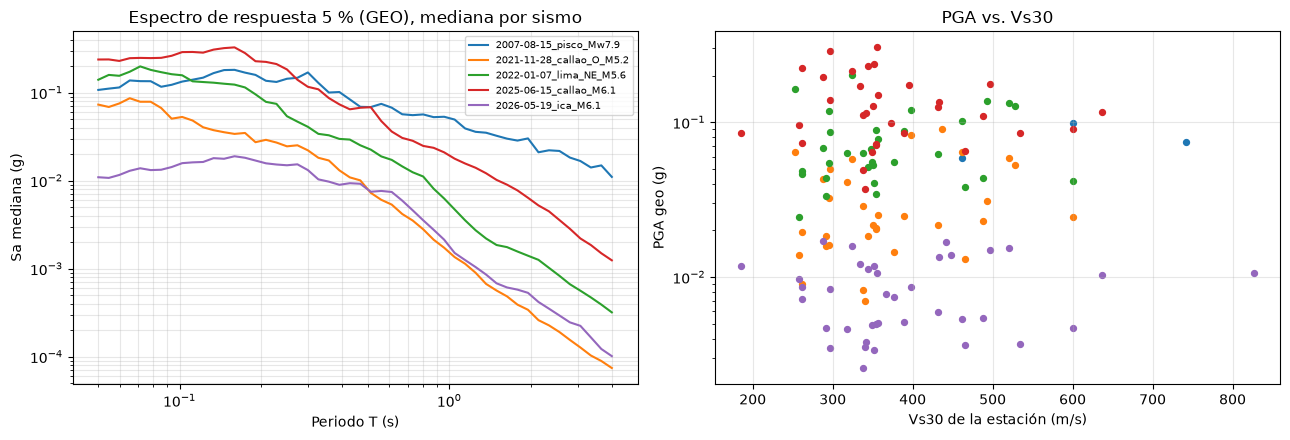

                          estaciones  pga_max_g  tp_mediano_s    vs30_min  \
evento                                                                      
2007-08-15_pisco_Mw7.9             3   0.099518       0.27350  461.099823   
2021-11-28_callao_O_M5.2          32   0.089834       0.07485  253.095337   
2022-01-07_lima_NE_M5.6           32   0.203045       0.07820  253.095337   
2025-06-15_callao_M6.1            32   0.304332       0.13370  185.081207   
2026-05-19_ica_M6.1               38   0.017056       0.14620  185.081207   

                            vs30_max  
evento                                
2007-08-15_pisco_Mw7.9    741.963928  
2021-11-28_callao_O_M5.2  600.000000  
2022-01-07_lima_NE_M5.6   600.000000  
2025-06-15_callao_M6.1    636.878113  
2026-05-19_ica_M6.1       827.195801  


In [26]:
import matplotlib.pyplot as plt

esp = (leer(spark, "silver", "espectros").where("componente = 'GEO'")
       .groupBy("evento", "T").agg(F.expr("percentile_approx(Sa, 0.5)").alias("Sa_mediana")).toPandas())
reg = leer(spark, "silver", "ondas_registros").select("evento", "estacion", "vs30", "pga_geo_g", "tp_s").toPandas()

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for ev, d in esp.sort_values("T").groupby("evento"):
    ax[0].loglog(d["T"], d["Sa_mediana"], label=ev)
ax[0].set(xlabel="Periodo T (s)", ylabel="Sa mediana (g)", title="Espectro de respuesta 5 % (GEO), mediana por sismo")
ax[0].legend(fontsize=7); ax[0].grid(True, which="both", alpha=.3)
for ev, d in reg.groupby("evento"):
    ax[1].scatter(d["vs30"], d["pga_geo_g"], label=ev, s=18)
ax[1].set(xlabel="Vs30 de la estación (m/s)", ylabel="PGA geo (g)", yscale="log", title="PGA vs. Vs30")
ax[1].grid(True, alpha=.3)
plt.tight_layout(); plt.show()

print(reg.groupby("evento").agg(estaciones=("estacion", "count"), pga_max_g=("pga_geo_g", "max"),
                                tp_mediano_s=("tp_s", "median"), vs30_min=("vs30", "min"), vs30_max=("vs30", "max")))

In [27]:
registros.unpersist()
print(f"Tiempo total: {(time.perf_counter()-INICIO)/60:,.1f} min")
display(inventario(spark, "silver"))

Tiempo total: 1.4 min


,tabla,filas,mb
0,silver.calidad_log,1357600,15.1
1,silver.distritos,49,0.0
2,silver.e030_parametros,4,0.0
3,silver.edificios,1921174,298.6
4,silver.espectros,27400,4.1
5,silver.eventos,5,0.0
6,silver.maxar_pares,5,0.0
7,silver.microzonificacion_periodos,23,0.0
8,silver.microzonificacion_zonas,17,0.0
9,silver.ondas_registros,137,3.4


# Parte 3 · Silver — territorio (distritos, suelo y edificios)

Paso 3 de la metodología.

| Tabla silver | Desde bronze | Qué se hace |
|---|---|---|
| `distritos` | `limites_inei` | Se filtran Lima y Callao (49 distritos); área, centroide y geometría WKT |
| `e030_parametros` | `e030_*` | Perfil de suelo → S, TP, TL para la Zona 4 (Z = 0.45 g) |
| `suelo` | `vs30_pixeles` | Cada píxel de Vs30 → distrito, perfil E.030 (S0–S3), S, TP, TL y celda H3 |
| `microzonificacion_zonas` | `microzonificacion_paginas` | Zonas I–V de cada estudio con su descripción y los perfiles/periodos que cita |
| `edificios` | `open_buildings` + `open_buildings_25d_teselas` | Confianza ≥ 0.75, recorte por distrito (point-in-polygon), H3, Vs30/perfil/TP, **altura → pisos → Tb** |
| `calidad_log` | — | Filas descartadas o imputadas en cada paso |

**Fórmulas** (de la metodología): `pisos = altura / 3` (redondeado, mínimo 1) y `Tb = 0.1 × pisos` (periodo fundamental aproximado de la E.030).

**Operaciones espaciales:** la metodología propone Apache Sedona, pero Sedona aún no publica una versión para Spark 4.2. Se usa el mismo esquema distribuido con `mapInPandas` + **Shapely 2 (STRtree)**: los 49 polígonos se difunden a todas las tareas y cada una resuelve su lote de puntos de forma vectorizada (equivalente a `ST_Within`).

In [28]:
import time
import numpy as np
import pandas as pd
from pyspark.sql import functions as F, types as T


INICIO = time.perf_counter()

CONFIANZA_MIN = 0.75
ALTURA_POR_PISO_M = 3.0
H3_RES_EDIFICIO = 9          # ~0.1 km² por hexágono
H3_RES_SUELO = 8             # ~0.7 km², del orden del píxel de Vs30 (~0.86 km²)

## 1. Distritos de Lima y Callao

In [29]:
import geopandas as gpd
import shapely

lim = leer(spark, "bronze", "limites_inei").where(F.col("NOMBPROV").isin(PROVINCIAS_ESTUDIO)).toPandas()
gdf = gpd.GeoDataFrame(lim, geometry=gpd.GeoSeries.from_wkt(lim["geometry_wkt"]), crs=4326)
invalidas = (~gdf.is_valid).sum()
gdf["geometry"] = gdf.geometry.make_valid()
utm = gdf.to_crs(EPSG_UTM_LIMA)
dist = pd.DataFrame({
    "ubigeo": gdf["IDDIST"], "distrito": gdf["NOMBDIST"], "provincia": gdf["NOMBPROV"], "departamento": gdf["NOMBDEP"],
    "area_km2": (utm.area / 1e6).round(3),
    "centroide_lon": utm.centroid.to_crs(4326).x, "centroide_lat": utm.centroid.to_crs(4326).y,
    "geometry_wkt": gdf.geometry.to_wkt(),
})
print(f"Distritos: {len(dist)} ({dist.provincia.value_counts().to_dict()}) | geometrías reparadas: {invalidas}")
escribir_delta(spark.createDataFrame(dist), "silver", "distritos")

# Polígonos que se difunden a las tareas de Spark (WKB)
POLIGONOS = spark.sparkContext.broadcast({"ubigeo": dist.ubigeo.tolist(), "distrito": dist.distrito.tolist(),
                                          "provincia": dist.provincia.tolist(), "wkb": shapely.to_wkb(gdf.geometry.values).tolist()})
BBOX = gdf.total_bounds
print("BBOX Lima+Callao:", BBOX.round(3))

Distritos: 49 ({'LIMA': 43, 'CALLAO': 6}) | geometrías reparadas: 2


  ✓ silver.distritos: 49 filas
BBOX Lima+Callao: [-77.194 -12.52  -76.621 -11.576]


## 2. Parámetros E.030 para Lima (Zona 4)

In [30]:
perfiles = leer(spark, "bronze", "e030_perfiles").drop("_fuente", "_archivo", "_fecha_ingesta")
factor_s = leer(spark, "bronze", "e030_factor_suelo").where(F.col("zona") == ZONA_E030_LIMA).select("perfil", "S")
z = leer(spark, "bronze", "e030_zonas").where(F.col("zona") == ZONA_E030_LIMA).first()["Z_g"]
e030 = (perfiles.join(factor_s, "perfil").withColumn("zona", F.lit(ZONA_E030_LIMA)).withColumn("Z_g", F.lit(z))
        .select("perfil", "descripcion", "vs30_min", "vs30_max", "zona", "Z_g", "S", "TP_s", "TL_s").orderBy("perfil"))
escribir_delta(e030, "silver", "e030_parametros")
E030 = {r["perfil"]: r.asDict() for r in e030.collect()}
e030.show(truncate=False)


def perfil_e030(col_vs30):
    """Tabla 2 de la E.030: S0 > 1500 ; S1 500–1500 ; S2 180–500 ; S3 < 180 (m/s)."""
    return (F.when(col_vs30 > E030["S0"]["vs30_min"], "S0")
             .when(col_vs30 > E030["S1"]["vs30_min"], "S1")
             .when(col_vs30 >= E030["S2"]["vs30_min"], "S2")
             .when(col_vs30.isNotNull(), "S3"))

  ✓ silver.e030_parametros: 4 filas


+------+-------------------------+--------+--------+----+----+----+----+----+
|perfil|descripcion              |vs30_min|vs30_max|zona|Z_g |S   |TP_s|TL_s|
+------+-------------------------+--------+--------+----+----+----+----+----+
|S0    |Roca dura                |1500.0  |NULL    |4   |0.45|0.8 |0.3 |3.0 |
|S1    |Roca o suelos muy rígidos|500.0   |1500.0  |4   |0.45|1.0 |0.4 |2.5 |
|S2    |Suelos intermedios       |180.0   |500.0   |4   |0.45|1.05|0.6 |2.0 |
|S3    |Suelos blandos           |NULL    |180.0   |4   |0.45|1.1 |1.0 |1.6 |
+------+-------------------------+--------+--------+----+----+----+----+----+



## 3. Asignación de distrito (point-in-polygon distribuido)
Función genérica que reciben `suelo` y `edificios`: agrega `ubigeo`, `distrito` y `provincia` a cada punto (lon, lat). Los puntos fuera de los 49 polígonos quedan con distrito nulo.

In [31]:
def asignar_distrito(lotes):
    p = POLIGONOS.value
    arbol = shapely.STRtree(shapely.from_wkb(p["wkb"]))
    ubigeo, distrito, provincia = (np.array(p[k], dtype=object) for k in ("ubigeo", "distrito", "provincia"))
    for pdf in lotes:
        puntos = shapely.points(pdf["lon"].to_numpy(), pdf["lat"].to_numpy())
        i_pt, i_pol = arbol.query(puntos, predicate="within")
        _, primero = np.unique(i_pt, return_index=True)            # un punto en el borde de 2 distritos: el primero
        i_pt, i_pol = i_pt[primero], i_pol[primero]
        for col, valores in (("ubigeo", ubigeo), ("distrito", distrito), ("provincia", provincia)):
            out = np.full(len(pdf), None, dtype=object)
            out[i_pt] = valores[i_pol]
            pdf[col] = out
        yield pdf


def esquema_mas_distrito(df):
    return T.StructType(df.schema.fields + [T.StructField(c, T.StringType()) for c in ("ubigeo", "distrito", "provincia")])

## 4. Suelo: Vs30 → perfil E.030
Cada píxel de Vs30 (~0.86 km²) recibe su perfil, S, TP y TL. Se guarda la grilla completa del rectángulo (`en_area_estudio` distingue los píxeles dentro de Lima/Callao) porque los edificios de la costa pueden caer en un píxel cuyo centro está en el mar.

In [32]:
import h3

vs = leer(spark, "bronze", "vs30_pixeles").select("fila", "col", "lon", "lat", "vs30")
vs_dist = vs.mapInPandas(asignar_distrito, schema=esquema_mas_distrito(vs))


@F.pandas_udf("string")
def h3_celda_8(lat: pd.Series, lon: pd.Series) -> pd.Series:
    return pd.Series([h3.latlng_to_cell(a, o, H3_RES_SUELO) for a, o in zip(lat, lon)])


e030_b = F.broadcast(e030.select("perfil", "S", "TP_s", "TL_s", "Z_g"))
suelo = (vs_dist
         .withColumn("perfil", perfil_e030(F.col("vs30")))
         .join(e030_b, "perfil", "left")
         .withColumn("en_area_estudio", F.col("distrito").isNotNull())
         .withColumn("h3_r8", h3_celda_8("lat", "lon"))
         .withColumnRenamed("TP_s", "TP").withColumnRenamed("TL_s", "TL")
         .select("fila", "col", "lon", "lat", "vs30", "perfil", "S", "TP", "TL", "Z_g",
                 "ubigeo", "distrito", "provincia", "en_area_estudio", "h3_r8"))
escribir_delta(suelo, "silver", "suelo")

s = leer(spark, "silver", "suelo")
s.where("en_area_estudio").groupBy("perfil").agg(F.count("*").alias("pixeles"), F.round(F.avg("vs30")).alias("vs30_medio")).orderBy("perfil").show()
registrar_calidad(spark, problemas(spark, [
    {"fuente": "vs30_usgs", "regla": "pixel_fuera_de_lima_callao", "accion": "fuera_de_alcance", "registro_id": None,
     "detalle": "píxel del rectángulo cuyo centro no cae en ningún distrito (mar u otras provincias); se conserva para el cruce con edificios costeros",
     "n_filas": s.where("NOT en_area_estudio").count()},
    {"fuente": "vs30_usgs", "regla": "vs30_nulo", "accion": "descartado", "registro_id": None,
     "detalle": "píxel sin valor de Vs30", "n_filas": s.where("vs30 IS NULL").count()},
]), "suelo")

  ✓ silver.suelo: 10,125 filas


+------+-------+----------+
|perfil|pixeles|vs30_medio|
+------+-------+----------+
|    S1|   2276|     736.0|
|    S2|   1102|     388.0|
+------+-------+----------+



  calidad_log [suelo] fuera_de_alcance pixel_fuera_de_lima_callao: 6,747
  calidad_log [suelo] descartado  vs30_nulo: 0


DataFrame[fuente: string, tabla: string, regla: string, accion: string, registro_id: string, detalle: string, n_filas: bigint, fecha: timestamp]

## 5. Microzonificación: zonas y periodos de cada estudio
Del texto de los PDF se extraen dos tablas:
- `microzonificacion_zonas`: la descripción de cada zona (I a V) de cada distrito y si menciona rellenos o licuación.
- `microzonificacion_periodos`: cada **rango de periodo predominante** citado (p. ej. "periodos de 0.20 a 0.30 s"), con su página y contexto; sirve para validar el TP de la E.030 y el periodo dominante medido con las ondas.

⚠️ **Limitación:** los polígonos de las zonas y los isoperiodos están como **imágenes** en los PDF; para corregir el suelo píxel a píxel hay que digitalizarlos (QGIS) y guardarlos en `raw/microzonificacion/zonas.geojson`. Mientras tanto, `suelo` y `edificios` marcan con `con_microzonificacion` los 4 distritos que tienen estudio.

In [33]:
import re

DISTRITO_PDF = {"cercado_de_lima": "LIMA", "comas": "COMAS", "la_molina": "LA MOLINA", "villa_el_salvador": "VILLA EL SALVADOR"}
ROMANOS = ["I", "II", "III", "IV", "V"]

def normalizar(texto):
    texto = re.sub(r"\s+", " ", texto)
    return re.sub(r"(\d)\s*([.,])\s*(\d)", r"\1.\3", texto)          # "0 .1" o "0,1" -> "0.1"


pag = leer(spark, "bronze", "microzonificacion_paginas").orderBy("distrito", "pagina").toPandas()
zonas, periodos = [], []
for archivo, d in pag.groupby("distrito"):
    for r in d.itertuples():
        t = normalizar(r.texto)
        for m in re.finditer(r"(\d\.\d+)\s*(?:s|seg\.?)?\s*(?:y|a|–|-|hasta)\s*(\d\.\d+)\s*(?:s|seg)\b", t):
            tmin, tmax = float(m.group(1)), float(m.group(2))
            if 0 < tmin < tmax <= 5:
                periodos.append({"archivo_pdf": archivo, "distrito": DISTRITO_PDF[archivo], "pagina": r.pagina,
                                 "T_min_s": tmin, "T_max_s": tmax, "contexto": t[max(0, m.start() - 200): m.end() + 60]})
    texto = normalizar(" ".join(d.sort_values("pagina")["texto"]))
    marcas = list(re.finditer(r"\bZona\s+(IV|V|I{1,3})\s*[:.\-–]?\s+(?=Esta|Comprende|Corresponde|Se |En |Está|Abarca|Conformad)", texto, re.I))
    for zona in ROMANOS:
        m = next((m for m in marcas if m.group(1).upper() == zona), None)
        if not m:
            continue
        sig = next((n.start() for n in marcas if n.start() > m.start() and n.group(1).upper() != zona), m.end() + 2500)
        desc = texto[m.end(): min(sig, m.end() + 2500)].strip()
        zonas.append({
            "archivo_pdf": archivo, "distrito": DISTRITO_PDF[archivo], "zona": zona,
            "descripcion": desc,
            "perfiles_e030": sorted(set(re.findall(r"\bS[0-4]\b", desc))),
            "periodos_s": sorted({float(x.replace(",", ".")) for x in re.findall(r"(\d[.,]\d{1,2})\s*(?:s\b|seg)", desc)}),
            "menciona_licuacion": bool(re.search(r"licuac", desc, re.I)),
            "menciona_relleno": bool(re.search(r"relleno|desmonte", desc, re.I)),
        })
micro = pd.DataFrame(zonas)
ESQ_ZONAS = ("archivo_pdf string, distrito string, zona string, descripcion string, perfiles_e030 array<string>, "
             "periodos_s array<double>, menciona_licuacion boolean, menciona_relleno boolean")
escribir_delta(spark.createDataFrame(micro, ESQ_ZONAS), "silver", "microzonificacion_zonas")
per = (pd.DataFrame(periodos, columns=["archivo_pdf", "distrito", "pagina", "T_min_s", "T_max_s", "contexto"])
       .drop_duplicates(["distrito", "pagina", "T_min_s", "T_max_s"]))
escribir_delta(spark.createDataFrame(per, "archivo_pdf string, distrito string, pagina long, T_min_s double, T_max_s double, contexto string"),
               "silver", "microzonificacion_periodos")
display(micro[["distrito", "zona", "menciona_relleno", "menciona_licuacion"]].assign(descripcion=micro.descripcion.str[:90]))
per[["distrito", "pagina", "T_min_s", "T_max_s"]]

  ✓ silver.microzonificacion_zonas: 17 filas


  ✓ silver.microzonificacion_periodos: 23 filas


,distrito,zona,menciona_relleno,menciona_licuacion,descripcion
0,LIMA,I,False,False,Esta zona está conformada por estratos potente...
1,LIMA,III,False,False,Esta z ona está conformada por depósitos de su...
2,LIMA,IV,False,False,Comprende el tramo entre el puente El Ejército...
3,LIMA,V,True,False,Corresponde a acumulaciones de materiales tran...
4,COMAS,I,False,False,Esta zona está conformada por los depósitos cu...
5,COMAS,II,True,False,Esta zona predomina en la región norte del dis...
6,COMAS,III,True,False,Esta zona está localizada en el sector Nor -Oe...
7,COMAS,IV,False,False,Esta zona está asociada a los taludes de fuert...
8,LA MOLINA,I,True,False,Está conformada por las laderas de los cerros ...
9,LA MOLINA,II,False,False,"Abarca la zona relativamente plana, que se ext..."


,distrito,pagina,T_min_s,T_max_s
0,LIMA,16,0.10,0.20
1,LIMA,17,0.20,0.30
2,LIMA,17,0.60,0.70
3,LIMA,19,0.10,0.30
4,LIMA,19,0.60,0.70
5,COMAS,30,0.05,0.22
7,COMAS,30,0.10,0.20
8,COMAS,31,0.10,0.20
9,COMAS,31,0.05,0.15
10,COMAS,31,0.16,0.22


## 6. Edificios
### 6.1 Recorte a Lima y Callao + confianza
Primero un filtro rápido por rectángulo (predicado empujado a Delta/Parquet), luego el point-in-polygon exacto con el centroide de cada edificio, y por último el umbral de confianza.

In [34]:
t0 = time.perf_counter()
ob = leer(spark, "bronze", "open_buildings")
n_bronze = ob.count()
en_bbox = ob.where(F.col("longitude").between(BBOX[0], BBOX[2]) & F.col("latitude").between(BBOX[1], BBOX[3]))

base = en_bbox.select(F.col("full_plus_code").alias("id"), F.col("longitude").alias("lon"), F.col("latitude").alias("lat"),
                      F.col("area_in_meters").alias("area_m2"), F.col("confidence").alias("confianza"),
                      F.col("geometry").alias("geometry_wkt"))
con_dist = base.mapInPandas(asignar_distrito, schema=esquema_mas_distrito(base)).cache()
n_lima = con_dist.where("distrito IS NOT NULL").count()
n_bbox = con_dist.count()

lima = con_dist.where("distrito IS NOT NULL")
baja_conf = lima.where(F.col("confianza") < CONFIANZA_MIN)
edif = lima.where(F.col("confianza") >= CONFIANZA_MIN)

dups = edif.groupBy("id").count().where("count > 1")
n_dups = dups.count()
if n_dups:
    edif = edif.dropDuplicates(["id"])
print(f"bronze: {n_bronze:,} | en rectángulo: {n_bbox:,} | dentro de Lima/Callao: {n_lima:,} | "
      f"confianza ≥ {CONFIANZA_MIN}: {n_lima - baja_conf.count():,} | ids duplicados: {n_dups} | {time.perf_counter()-t0:,.0f} s")

bronze: 7,219,950 | en rectángulo: 3,198,445 | dentro de Lima/Callao: 3,124,896 | confianza ≥ 0.75: 1,921,176 | ids duplicados: 2 | 17 s


### 6.2 H3, coordenadas UTM y suelo
- `h3_id` (resolución 9) para agregar y mapear; `h3_r8` para cruzar con el suelo.
- Vs30, perfil, S y TP: se une con el píxel de `silver.suelo` que contiene al centroide (clave `fila, col`).

In [35]:
from pyproj import Transformer

g = leer(spark, "bronze", "vs30_pixeles").select("grid_origen_lon", "grid_origen_lat", "grid_res").first()
ESQ_H3_UTM = T.StructType(edif.schema.fields + [T.StructField("h3_id", T.StringType()), T.StructField("h3_r8", T.StringType()),
                                                 T.StructField("x_utm", T.DoubleType()), T.StructField("y_utm", T.DoubleType())])


def h3_y_utm(lotes):
    a_utm = Transformer.from_crs(4326, EPSG_UTM_LIMA, always_xy=True)
    for pdf in lotes:
        lat, lon = pdf["lat"].to_numpy(), pdf["lon"].to_numpy()
        celdas9 = [h3.latlng_to_cell(a, o, H3_RES_EDIFICIO) for a, o in zip(lat, lon)]
        pdf["h3_id"] = celdas9
        pdf["h3_r8"] = [h3.cell_to_parent(c, H3_RES_SUELO) for c in celdas9]
        pdf["x_utm"], pdf["y_utm"] = a_utm.transform(lon, lat)
        yield pdf


suelo_b = F.broadcast(leer(spark, "silver", "suelo").select("fila", "col", "vs30", "perfil", "S", "TP", "TL"))
edif = (edif.mapInPandas(h3_y_utm, schema=ESQ_H3_UTM)
        .withColumn("col", F.floor((F.col("lon") - g.grid_origen_lon) / g.grid_res).cast("int"))
        .withColumn("fila", F.floor((g.grid_origen_lat - F.col("lat")) / g.grid_res).cast("int"))
        .join(suelo_b, ["fila", "col"], "left")
        .drop("fila", "col"))

### 6.3 Altura (Open Buildings 2.5D) → pisos → Tb
Cada edificio se asigna a la tesela de altura que contiene su centroide (UTM). Spark reparte los edificios **por tesela**, así cada tarea abre solo los rásters que necesita (4 m/píxel, ~40 MB en memoria) y lee la altura de todos sus edificios de una vez:
1. Altura del píxel del **centroide**.
2. Si ese píxel no tiene edificio (centroide desplazado en techos irregulares), **máximo de la ventana 3×3** (12 × 12 m).
3. Si tampoco hay altura: `pisos = 1` imputado y se registra en `calidad_log`.

In [36]:
teselas = leer(spark, "bronze", "open_buildings_25d_teselas").select("tesela", "_archivo", "xmin", "ymin", "xmax", "ymax", "res_m", "nodata").toPandas()
TESELAS = spark.sparkContext.broadcast(teselas.to_dict("list"))
print(f"Teselas de altura: {len(teselas)} | resolución: {teselas.res_m.unique()} m")

ESQ_TESELA = T.StructType(edif.schema.fields + [T.StructField("tesela", T.StringType())])


def asignar_tesela(lotes):
    t = TESELAS.value
    for pdf in lotes:
        x, y = pdf["x_utm"].to_numpy(), pdf["y_utm"].to_numpy()
        out = np.full(len(pdf), None, dtype=object)
        for i, nombre in enumerate(t["tesela"]):
            dentro = (x >= t["xmin"][i]) & (x < t["xmax"][i]) & (y > t["ymin"][i]) & (y <= t["ymax"][i])
            out[dentro & (out == None)] = nombre          # noqa: E711 (comparación elemento a elemento)
        pdf["tesela"] = out
        yield pdf


ESQ_ALTURA = T.StructType(ESQ_TESELA.fields + [T.StructField("altura_m", T.DoubleType()), T.StructField("altura_metodo", T.StringType())])


def leer_alturas(lotes):
    import rasterio
    t = TESELAS.value
    idx = {n: i for i, n in enumerate(t["tesela"])}
    cache = {}
    for pdf in lotes:
        alt = np.full(len(pdf), np.nan)
        metodo = np.full(len(pdf), "sin_tesela", dtype=object)
        for nombre, sub in pdf.groupby("tesela", dropna=True):
            i = idx[nombre]
            if nombre not in cache:
                if len(cache) >= 2:
                    cache.pop(next(iter(cache)))
                with rasterio.open(t["_archivo"][i]) as src:
                    h = src.read(1).astype("float32")
                h[(h == t["nodata"][i]) | ~np.isfinite(h)] = 0.0
                # máximo 3x3 precalculado sobre el mismo arreglo (desplazamientos con borde 0, sin copias grandes)
                hp = np.pad(h, 1)
                h3x3 = h.copy()
                for dy in (-1, 0, 1):
                    for dx in (-1, 0, 1):
                        np.maximum(h3x3, hp[1 + dy: hp.shape[0] - 1 + dy, 1 + dx: hp.shape[1] - 1 + dx], out=h3x3)
                cache[nombre] = (h, h3x3)
            h, h3x3 = cache[nombre]
            res = t["res_m"][i]
            colp = np.clip(((sub["x_utm"].to_numpy() - t["xmin"][i]) // res).astype(int), 0, h.shape[1] - 1)
            filp = np.clip(((t["ymax"][i] - sub["y_utm"].to_numpy()) // res).astype(int), 0, h.shape[0] - 1)
            centro, vecinos = h[filp, colp], h3x3[filp, colp]
            pos = pdf.index.get_indexer(sub.index)
            alt[pos] = np.where(centro > 0, centro, np.where(vecinos > 0, vecinos, np.nan))
            metodo[pos] = np.where(centro > 0, "centroide", np.where(vecinos > 0, "max_3x3", "sin_altura"))
        pdf["altura_m"] = alt
        pdf["altura_metodo"] = metodo
        yield pdf


con_altura = (edif.mapInPandas(asignar_tesela, schema=ESQ_TESELA)
              .repartition(48, "tesela").sortWithinPartitions("tesela")
              .mapInPandas(leer_alturas, schema=ESQ_ALTURA))

pisos = F.greatest(F.lit(1), F.round(F.col("altura_m") / ALTURA_POR_PISO_M)).cast("int")
edificios = (con_altura
    .withColumn("altura_imputada", F.col("altura_m").isNull())
    .withColumn("pisos", F.when(F.col("altura_imputada"), F.lit(1)).otherwise(pisos))
    .withColumn("Tb", F.round(0.1 * F.col("pisos"), 2))
    .withColumn("Tb_TP", F.round(F.col("Tb") / F.col("TP"), 3))
    .withColumn("con_microzonificacion", F.col("distrito").isin(list(DISTRITO_PDF.values())))
    .withColumnRenamed("perfil", "tipo_suelo")
    .select("id", "ubigeo", "distrito", "provincia", "h3_id", "h3_r8", "lon", "lat", "x_utm", "y_utm",
            "area_m2", "confianza", "altura_m", "altura_metodo", "altura_imputada", "pisos", "Tb",
            "vs30", "tipo_suelo", "S", "TP", "TL", "Tb_TP", "con_microzonificacion", "tesela", "geometry_wkt"))

t0 = time.perf_counter()
n_edif = escribir_delta(edificios, "silver", "edificios", particion="provincia")
print(f"Escritura de edificios: {(time.perf_counter()-t0)/60:,.1f} min")

Teselas de altura: 44 | resolución: [4.] m


  ✓ silver.edificios: 1,921,174 filas
Escritura de edificios: 1.1 min


### 6.4 Registro de calidad de edificios

In [37]:
e = leer(spark, "silver", "edificios")
agregados = problemas(spark, [
    {"fuente": "open_buildings_v3", "regla": "fuera_del_rectangulo_lima", "accion": "fuera_de_alcance", "registro_id": None,
     "detalle": "edificio de la tesela 911 fuera del rectángulo de Lima/Callao", "n_filas": n_bronze - n_bbox},
    {"fuente": "open_buildings_v3", "regla": "fuera_de_distritos_lima_callao", "accion": "fuera_de_alcance", "registro_id": None,
     "detalle": "centroide dentro del rectángulo pero fuera de los 49 distritos (ST_Within)", "n_filas": n_bbox - n_lima},
    {"fuente": "open_buildings_v3", "regla": "id_duplicado", "accion": "descartado", "registro_id": None,
     "detalle": "full_plus_code repetido; se conserva una fila", "n_filas": n_dups},
])
por_fila = (baja_conf.select(F.lit("open_buildings_v3").alias("fuente"), F.lit(f"confianza<{CONFIANZA_MIN}").alias("regla"),
                             F.lit("descartado").alias("accion"), F.col("id").alias("registro_id"),
                             F.format_string("confianza=%.3f", "confianza").alias("detalle"), F.lit(1).alias("n_filas"))
            .unionByName(e.where("altura_imputada").select(
                F.lit("open_buildings_25d").alias("fuente"), F.lit("sin_altura_2.5D").alias("regla"), F.lit("imputado").alias("accion"),
                F.col("id").alias("registro_id"), F.concat(F.lit("pisos=1; tesela="), F.coalesce("tesela", F.lit("ninguna"))).alias("detalle"),
                F.lit(1).alias("n_filas")))
            .unionByName(e.where("vs30 IS NULL").select(
                F.lit("vs30_usgs").alias("fuente"), F.lit("edificio_sin_vs30").alias("regla"), F.lit("advertencia").alias("accion"),
                F.col("id").alias("registro_id"), F.lit("el píxel de Vs30 no existe en la ventana").alias("detalle"), F.lit(1).alias("n_filas"))))
registrar_calidad(spark, agregados.unionByName(por_fila), "edificios")
con_dist.unpersist()

  calidad_log [edificios] fuera_de_alcance fuera_del_rectangulo_lima: 4,021,505
  calidad_log [edificios] descartado  confianza<0.75: 1,203,720
  calidad_log [edificios] imputado    sin_altura_2.5D: 152,941
  calidad_log [edificios] fuera_de_alcance fuera_de_distritos_lima_callao: 73,549
  calidad_log [edificios] descartado  id_duplicado: 2


DataFrame[id: string, lon: double, lat: double, area_m2: double, confianza: double, geometry_wkt: string, ubigeo: string, distrito: string, provincia: string]

## 7. Revisión de silver.edificios

In [38]:
resumen = (e.groupBy("provincia").agg(
    F.count("*").alias("edificios"), F.round(F.avg("pisos"), 2).alias("pisos_medio"), F.max("pisos").alias("pisos_max"),
    F.round(100 * F.avg(F.col("altura_imputada").cast("int")), 1).alias("pct_altura_imputada"),
    F.round(F.avg("vs30")).alias("vs30_medio")))
resumen.show()
e.groupBy("tipo_suelo").count().orderBy("tipo_suelo").show()
e.groupBy("altura_metodo").count().show()
dist_rank = (e.groupBy("distrito").agg(F.count("*").alias("edificios"), F.round(F.avg("vs30")).alias("vs30_medio"),
                                       F.round(F.avg("pisos"), 2).alias("pisos_medio"),
                                       F.round(100 * F.avg((F.abs(F.col("Tb_TP") - 1) < 0.2).cast("double")), 1).alias("pct_Tb_cerca_TP"))
             .orderBy("vs30_medio"))
dist_rank.show(10, truncate=False)

+---------+---------+-----------+---------+-------------------+----------+
|provincia|edificios|pisos_medio|pisos_max|pct_altura_imputada|vs30_medio|
+---------+---------+-----------+---------+-------------------+----------+
|     LIMA|  1732211|       1.74|       29|                7.2|     513.0|
|   CALLAO|   188963|       1.76|       21|               15.0|     443.0|
+---------+---------+-----------+---------+-------------------+----------+



+----------+-------+
|tipo_suelo|  count|
+----------+-------+
|        S1| 832959|
|        S2|1088215|
+----------+-------+



+-------------+-------+
|altura_metodo|  count|
+-------------+-------+
|    centroide|1718102|
|      max_3x3|  50131|
|   sin_altura| 152941|
+-------------+-------+



+--------------------------+---------+----------+-----------+---------------+
|distrito                  |edificios|vs30_medio|pisos_medio|pct_Tb_cerca_TP|
+--------------------------+---------+----------+-----------+---------------+
|CALLAO                    |66746    |309.0     |2.4        |5.2            |
|BELLAVISTA                |4415     |315.0     |2.78       |6.3            |
|LOS OLIVOS                |17288    |320.0     |2.72       |5.6            |
|SAN MARTIN DE PORRES      |89021    |326.0     |2.56       |6.8            |
|MAGDALENA VIEJA           |6503     |336.0     |2.87       |8.5            |
|CARMEN DE LA LEGUA REYNOSO|1502     |336.0     |2.71       |4.3            |
|JESUS MARIA               |4857     |339.0     |3.55       |10.5           |
|BREÑA                     |615      |340.0     |3.06       |10.4           |
|LINCE                     |3052     |342.0     |3.26       |9.3            |
|LIMA                      |45678    |347.0     |2.8        |10.

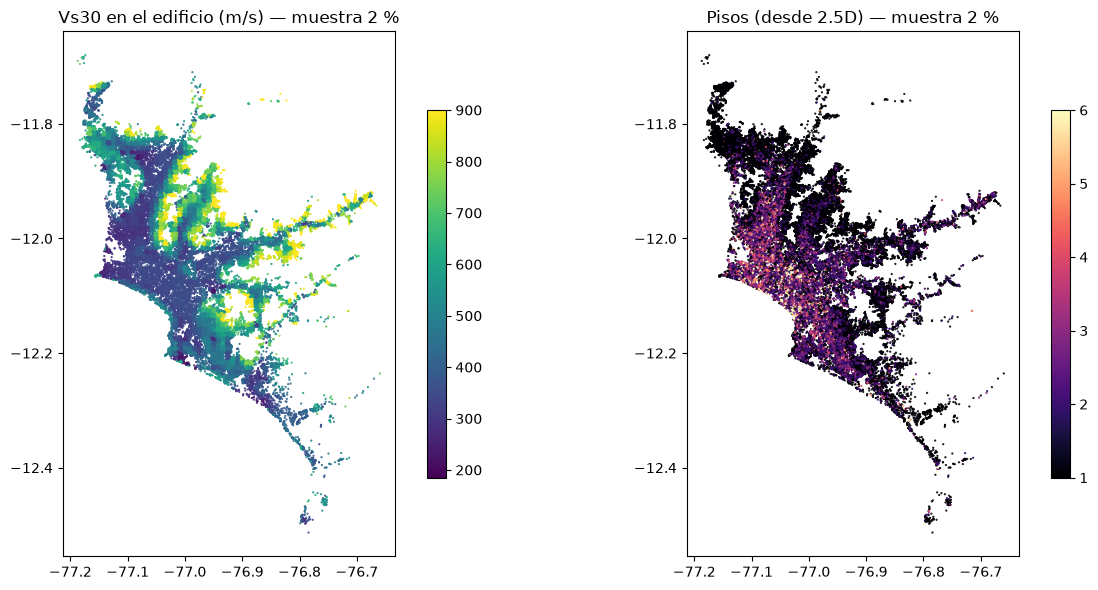

In [39]:
import matplotlib.pyplot as plt

muestra = e.sample(0.02, seed=1).select("lon", "lat", "vs30", "pisos").toPandas()
fig, ax = plt.subplots(1, 2, figsize=(13, 6))
for a, col, titulo, cmap in ((ax[0], "vs30", "Vs30 en el edificio (m/s)", "viridis"), (ax[1], "pisos", "Pisos (desde 2.5D)", "magma")):
    sc = a.scatter(muestra.lon, muestra.lat, c=muestra[col], s=0.3, cmap=cmap,
                   vmax=None if col == "vs30" else np.percentile(muestra.pisos, 99))
    plt.colorbar(sc, ax=a, shrink=.7); a.set_title(titulo + " — muestra 2 %"); a.set_aspect("equal")
plt.tight_layout(); plt.show()

In [40]:
print(f"Tiempo total: {(time.perf_counter()-INICIO)/60:,.1f} min")
display(inventario(spark, "silver"))

Tiempo total: 2.2 min


,tabla,filas,mb
0,silver.calidad_log,1357600,30.2
1,silver.distritos,49,0.0
2,silver.e030_parametros,4,0.0
3,silver.edificios,1921174,597.3
4,silver.espectros,27400,4.1
5,silver.eventos,5,0.0
6,silver.maxar_pares,5,0.0
7,silver.microzonificacion_periodos,23,0.0
8,silver.microzonificacion_zonas,17,0.1
9,silver.ondas_registros,137,3.4


# Parte 4 · Silver — validación (Turquía) y detección de onda P (STEAD)

Prepara en silver las fuentes que usarán los pasos 7 (validación en Turquía) y 8 (tiempo real):

| Tabla silver | Desde bronze | Qué se hace |
|---|---|---|
| `xbd_escenas` | `xbd_indice` + Parquet de raw | Se decodifican las máscaras PNG y se cuenta el daño por escena (sin daño, leve, severo, destruido); tipo de desastre |
| `maxar_pares` | `maxar_catalogo` + `maxar_imagenes` | Un par antes/después por zona con fechas, resolución, nubes, ángulo y huella en WGS84 |
| `shakemap_turquia` | `shakemap_grid` | PGA y Sa en **g**, PGV en cm/s, Vs30, celda H3 y marca de los puntos dentro de las zonas Maxar |
| `stead_trazas` | `stead_metadata` | Trazas tipadas: sismo/ruido, llegadas P y S en segundos, SNR por componente, magnitud y distancia |

Clases de daño de xBD en `t2_mask` (convención de xView2): 0 fondo · 1 sin daño · 2 daño leve · 3 daño severo · 4 destruido.

In [41]:
import io, time
import numpy as np
import pandas as pd
from pyspark.sql import functions as F, types as T


INICIO = time.perf_counter()

## 1. xBD — daño por escena
Spark lee del Parquet **solo** las columnas de máscaras (lectura columnar con poda de campos anidados: no se cargan las imágenes RGB) y una Pandas UDF decodifica cada PNG y cuenta píxeles por clase.

In [42]:
from PIL import Image

CLASES = {1: "px_sin_dano", 2: "px_dano_leve", 3: "px_dano_severo", 4: "px_destruido"}
ESQ_MASCARAS = T.StructType([
    T.StructField("image_name", T.StringType()), T.StructField("_archivo", T.StringType()),
    T.StructField("px_edificio_pre", T.LongType()), T.StructField("px_edificio_post", T.LongType()),
    *[T.StructField(c, T.LongType()) for c in CLASES.values()],
    T.StructField("ancho", T.IntegerType()), T.StructField("alto", T.IntegerType()),
    T.StructField("error", T.StringType()),
])


def contar_mascaras(lotes):
    for pdf in lotes:
        filas = []
        for r in pdf.to_dict("records"):          # itertuples() renombra las columnas que empiezan con "_"
            fila = {"image_name": r["image_name"], "_archivo": r["_archivo"], "error": None}
            try:
                pre = np.asarray(Image.open(io.BytesIO(r["t1_mask"])))
                post = np.asarray(Image.open(io.BytesIO(r["t2_mask"])))
                cuentas = np.bincount(post.ravel(), minlength=5)
                fila.update(px_edificio_pre=int((pre > 0).sum()), px_edificio_post=int((post > 0).sum()),
                            alto=post.shape[0], ancho=post.shape[1],
                            **{nombre: int(cuentas[k]) for k, nombre in CLASES.items()})
            except Exception as e:
                fila["error"] = f"{type(e).__name__}: {e}"[:200]
            filas.append(fila)
        yield pd.DataFrame(filas).reindex(columns=[f.name for f in ESQ_MASCARAS.fields])


t0 = time.perf_counter()
mascaras = (spark.read.parquet(ruta_raw("xbd", "data", "*.parquet"))
            .select("image_name", F.col("_metadata.file_path").alias("_archivo"),
                    F.col("t1_mask.bytes").alias("t1_mask"), F.col("t2_mask.bytes").alias("t2_mask"))
            .mapInPandas(contar_mascaras, schema=ESQ_MASCARAS))

indice = leer(spark, "bronze", "xbd_indice").select("image_name", "_archivo", "split")
TIPO_DESASTRE = {"earthquake": "sismo", "tsunami": "tsunami", "flooding": "inundacion", "fire": "incendio",
                 "hurricane": "huracan", "volcano": "volcan", "tornado": "tornado", "wildfire": "incendio"}
tipo = F.lit(None).cast("string")
for clave, valor in TIPO_DESASTRE.items():
    tipo = F.when(F.col("desastre").contains(clave), valor).otherwise(tipo)

px_post = F.col("px_edificio_post")
xbd = (mascaras.join(indice, ["image_name", "_archivo"], "left")
       .withColumn("escena", F.regexp_extract("image_name", r"/([^/]+)$", 1))
       .withColumn("desastre", F.regexp_extract("escena", r"^(.+)_\d+$", 1))
       .withColumn("tipo_desastre", tipo)
       .withColumn("relevante_sismo", F.col("tipo_desastre").isin("sismo", "tsunami"))
       .withColumn("pct_danado", F.when(px_post > 0, 100 * (F.col("px_dano_leve") + F.col("px_dano_severo") + F.col("px_destruido")) / px_post))
       .withColumn("pct_severo_o_destruido", F.when(px_post > 0, 100 * (F.col("px_dano_severo") + F.col("px_destruido")) / px_post))
       .withColumn("clase_dominante", F.when(px_post == 0, "sin_edificios").otherwise(
           F.element_at(F.array(*[F.lit(n.replace("px_", "")) for n in CLASES.values()]),
                        F.array_position(F.array(*[F.col(n) for n in CLASES.values()]),
                                         F.greatest(*[F.col(n) for n in CLASES.values()])).cast("int"))))
       .select("image_name", "escena", "split", "desastre", "tipo_desastre", "relevante_sismo", "ancho", "alto",
               "px_edificio_pre", "px_edificio_post", *CLASES.values(), "pct_danado", "pct_severo_o_destruido",
               "clase_dominante", "error", "_archivo"))
escribir_delta(xbd, "silver", "xbd_escenas", particion="split")
print(f"xBD: {(time.perf_counter()-t0)/60:,.1f} min")

x = leer(spark, "silver", "xbd_escenas")
registrar_calidad(spark, x.where("error IS NOT NULL OR px_edificio_post = 0").select(
    F.lit("xbd").alias("fuente"),
    F.when(F.col("error").isNotNull(), "mascara_ilegible").otherwise("escena_sin_edificios").alias("regla"),
    F.when(F.col("error").isNotNull(), "descartado").otherwise("advertencia").alias("accion"),
    F.col("image_name").alias("registro_id"), F.coalesce("error", F.lit("t2_mask sin edificios: útil solo como negativo")).alias("detalle"),
    F.lit(1).alias("n_filas")), "xbd_escenas")
x.groupBy("tipo_desastre").agg(F.count("*").alias("escenas"), F.sum("px_destruido").alias("px_destruido"),
                               F.round(F.avg("pct_danado"), 1).alias("pct_danado_medio")).orderBy(F.desc("escenas")).show()

  ✓ silver.xbd_escenas: 8,043 filas
xBD: 2.6 min


  calidad_log [xbd_escenas] advertencia escena_sin_edificios: 934


+-------------+-------+------------+----------------+
|tipo_desastre|escenas|px_destruido|pct_danado_medio|
+-------------+-------+------------+----------------+
|     incendio|   3636|    11527876|            24.9|
|      huracan|   2023|     2701216|            56.1|
|   inundacion|   1021|      228932|            36.1|
|      tornado|    658|     5382465|            23.2|
|      tsunami|    301|     3634632|            16.7|
|       volcan|    211|      292936|            14.2|
|        sismo|    193|        5549|             1.0|
+-------------+-------+------------+----------------+



## 2. Maxar — pares antes/después

In [43]:
from pyproj import Transformer
from shapely.geometry import box
from shapely.ops import transform as transformar

img = leer(spark, "bronze", "maxar_imagenes").toPandas()
# bronze guarda el catálogo como texto: la fecha se toma literal del texto UTC ("2023-02-08 08:12:..+00:00")
cat = (leer(spark, "bronze", "maxar_catalogo")
       .select("quadkey", "catalog_id", F.substring("datetime", 1, 10).alias("fecha"), "platform",
               F.col("gsd").cast("double").alias("gsd"), F.col("view_off_nadir").cast("double").alias("off_nadir"),
               F.col("tile_clouds_percent").cast("double").alias("nubes_pct"))
       .dropDuplicates(["quadkey", "catalog_id", "fecha"]).toPandas())
img = img.merge(cat, on=["quadkey", "catalog_id", "fecha"], how="left")


def huella_wgs84(r):
    a_wgs = Transformer.from_crs(int(r.epsg), 4326, always_xy=True).transform
    return transformar(a_wgs, box(r.xmin, r.ymin, r.xmax, r.ymax))


img["huella"] = img.apply(huella_wgs84, axis=1)
pares = []
for qk, d in img.groupby("quadkey"):
    antes, despues = d[d.momento == "antes"].iloc[0], d[d.momento == "despues"].iloc[0]
    comun = antes.huella.intersection(despues.huella)
    pares.append({
        "quadkey": qk,
        "fecha_antes": antes.fecha, "fecha_despues": despues.fecha,
        "dias_entre": (pd.Timestamp(despues.fecha) - pd.Timestamp(antes.fecha)).days,
        "catalog_antes": antes.catalog_id, "catalog_despues": despues.catalog_id,
        "satelite_antes": antes.platform, "satelite_despues": despues.platform,
        "gsd_antes_m": antes.gsd, "gsd_despues_m": despues.gsd,
        "off_nadir_antes": antes.off_nadir, "off_nadir_despues": despues.off_nadir,
        "nubes_antes_pct": antes.nubes_pct, "nubes_despues_pct": despues.nubes_pct,
        "res_m": float(antes.res_m), "epsg": int(antes.epsg),
        "solape_pct": round(100 * comun.area / antes.huella.area, 1),
        "centro_lon": comun.centroid.x, "centro_lat": comun.centroid.y,
        "huella_wkt": comun.wkt,
        "archivo_antes": antes._archivo, "archivo_despues": despues._archivo,
    })
maxar = pd.DataFrame(pares)
escribir_delta(spark.createDataFrame(maxar), "silver", "maxar_pares")
maxar[["quadkey", "fecha_antes", "fecha_despues", "dias_entre", "gsd_antes_m", "gsd_despues_m", "solape_pct", "centro_lon", "centro_lat"]]

  ✓ silver.maxar_pares: 5 filas


,quadkey,fecha_antes,fecha_despues,dias_entre,gsd_antes_m,gsd_despues_m,solape_pct,centro_lon,centro_lat
0,031133012123,2022-12-27,2023-02-07,42,0.49,0.31,100.0,36.610510,37.044686
1,031133012301,2022-12-27,2023-02-07,42,0.49,0.48,100.0,36.611921,36.999653
2,031133102032,2023-01-02,2023-02-08,37,0.53,0.82,100.0,37.341072,37.057156
3,031133102033,2023-01-02,2023-02-08,37,0.52,0.82,100.0,37.397287,37.057929
4,031133113102,2023-01-02,2023-02-09,38,0.55,0.48,100.0,38.802908,37.158736


## 3. ShakeMap Turquía
Conversión de unidades: PGA y PSA vienen en **%g** → se dividen entre 100 para tener **g**. `SVEL` es el Vs30 (m/s) que usó el ShakeMap.

In [44]:
import h3
import shapely

HUELLAS = spark.sparkContext.broadcast({"quadkey": maxar.quadkey.tolist(),
                                        "wkb": shapely.to_wkb(shapely.from_wkt(maxar.huella_wkt.tolist())).tolist()})


def marcar_zona_maxar(lotes):
    arbol = shapely.STRtree(shapely.from_wkb(HUELLAS.value["wkb"]))
    qks = np.array(HUELLAS.value["quadkey"], dtype=object)
    for pdf in lotes:
        i_pt, i_pol = arbol.query(shapely.points(pdf["lon"].to_numpy(), pdf["lat"].to_numpy()), predicate="within")
        out = np.full(len(pdf), None, dtype=object)
        out[i_pt] = qks[i_pol]
        pdf["quadkey_maxar"] = out
        pdf["h3_r8"] = [h3.latlng_to_cell(a, o, 8) for a, o in zip(pdf["lat"], pdf["lon"])]
        yield pdf


sm = leer(spark, "bronze", "shakemap_grid")
sm = sm.select(F.col("LON").alias("lon"), F.col("LAT").alias("lat"), F.col("MMI").alias("mmi"),
               (F.col("PGA") / 100).alias("pga_g"), F.col("PGV").alias("pgv_cms"),
               (F.col("PSA03") / 100).alias("sa03_g"), (F.col("PSA06") / 100).alias("sa06_g"),
               (F.col("PSA10") / 100).alias("sa10_g"), (F.col("PSA30") / 100).alias("sa30_g"),
               F.col("SVEL").alias("vs30"), "event_id", "magnitud", "shakemap_version")
esq = T.StructType(sm.schema.fields + [T.StructField("quadkey_maxar", T.StringType()), T.StructField("h3_r8", T.StringType())])
shakemap = sm.mapInPandas(marcar_zona_maxar, schema=esq).withColumn("en_zona_maxar", F.col("quadkey_maxar").isNotNull())
escribir_delta(shakemap, "silver", "shakemap_turquia")

st = leer(spark, "silver", "shakemap_turquia")
st.where("en_zona_maxar").groupBy("quadkey_maxar").agg(
    F.count("*").alias("puntos"), F.round(F.avg("pga_g"), 3).alias("pga_g"), F.round(F.avg("sa03_g"), 3).alias("sa03_g"),
    F.round(F.avg("sa10_g"), 3).alias("sa10_g"), F.round(F.avg("mmi"), 1).alias("mmi"), F.round(F.avg("vs30")).alias("vs30")).show()
registrar_calidad(spark, st.where("pga_g IS NULL OR vs30 IS NULL OR pga_g < 0").select(
    F.lit("shakemap_usgs").alias("fuente"), F.lit("valor_nulo_o_negativo").alias("regla"), F.lit("advertencia").alias("accion"),
    F.format_string("%.4f,%.4f", "lon", "lat").alias("registro_id"), F.lit("PGA o Vs30 inválido").alias("detalle"),
    F.lit(1).alias("n_filas")), "shakemap_turquia")

  ✓ silver.shakemap_turquia: 467,929 filas


+-------------+------+-----+------+------+---+-----+
|quadkey_maxar|puntos|pga_g|sa03_g|sa10_g|mmi| vs30|
+-------------+------+-----+------+------+---+-----+
| 031133102033|    35|0.223| 0.465| 0.217|7.5|377.0|
| 031133102032|    39| 0.24|  0.54| 0.232|7.6|364.0|
| 031133113102|    35|0.099|  0.19| 0.137|6.0|397.0|
| 031133012301|    38|0.684| 1.611| 0.956|8.9|565.0|
| 031133012123|    42|0.801| 1.607| 1.033|8.9|579.0|
+-------------+------+-----+------+------+---+-----+



DataFrame[fuente: string, tabla: string, regla: string, accion: string, registro_id: string, detalle: string, n_filas: bigint, fecha: timestamp]

## 4. STEAD — trazas para el detector de onda P
Muestreo de STEAD: 100 Hz, 60 s por traza (6000 muestras, 3 componentes E-N-Z). Las llegadas vienen en número de muestra → se pasan a segundos. `snr_db` viene como texto `"[e n z]"`.

In [45]:
FS_STEAD = 100.0
sd = leer(spark, "bronze", "stead_metadata")
snr = F.split(F.regexp_replace("snr_db", r"[\[\]]", ""), r"\s+")
stead = (sd
    .withColumn("snr_arr", F.filter(snr, lambda s: s != ""))
    .select("trace_name", "trace_category", (F.col("trace_category") == "earthquake_local").alias("es_sismo"),
            "network_code", "receiver_code", "receiver_type", "receiver_latitude", "receiver_longitude",
            "p_arrival_sample", "p_status", "p_weight", "s_arrival_sample", "s_status", "s_weight",
            (F.col("p_arrival_sample") / FS_STEAD).alias("p_segundos"), (F.col("s_arrival_sample") / FS_STEAD).alias("s_segundos"),
            ((F.col("s_arrival_sample") - F.col("p_arrival_sample")) / FS_STEAD).alias("s_menos_p_s"),
            "source_magnitude", "source_magnitude_type", "source_distance_km", "source_depth_km",
            "source_latitude", "source_longitude", "back_azimuth_deg",
            F.col("snr_arr")[0].cast("double").alias("snr_e_db"), F.col("snr_arr")[1].cast("double").alias("snr_n_db"),
            F.col("snr_arr")[2].cast("double").alias("snr_z_db"),
            "coda_end_sample", "trace_start_time", "_archivo_hdf5"))
fallas = stead.where(F.col("es_sismo") & (F.col("p_arrival_sample").isNull() | F.col("source_magnitude").isNull()))
stead_ok = stead.join(fallas.select("trace_name"), "trace_name", "left_anti")
escribir_delta(stead_ok, "silver", "stead_trazas")
registrar_calidad(spark, fallas.select(
    F.lit("stead").alias("fuente"), F.lit("sismo_sin_llegada_P_o_magnitud").alias("regla"), F.lit("descartado").alias("accion"),
    F.col("trace_name").alias("registro_id"), F.lit("no sirve para entrenar el detector de onda P").alias("detalle"),
    F.lit(1).alias("n_filas")), "stead_trazas")

s = leer(spark, "silver", "stead_trazas")
s.groupBy("trace_category").agg(F.count("*").alias("trazas"), F.round(F.avg("source_magnitude"), 2).alias("mag_media"),
                                F.round(F.expr("percentile_approx(p_segundos, 0.5)"), 1).alias("p_mediana_s"),
                                F.round(F.avg("snr_z_db"), 1).alias("snr_z_medio")).show()

  ✓ silver.stead_trazas: 200,000 filas


+----------------+------+---------+-----------+-----------+
|  trace_category|trazas|mag_media|p_mediana_s|snr_z_medio|
+----------------+------+---------+-----------+-----------+
|earthquake_local|200000|     1.33|        7.0|        NaN|
+----------------+------+---------+-----------+-----------+



## Resumen

In [46]:
print(f"Tiempo total: {(time.perf_counter()-INICIO)/60:,.1f} min")
display(inventario(spark, "silver"))
display(leer(spark, "silver", "calidad_log").groupBy("tabla", "accion").agg(F.sum("n_filas").alias("filas")).orderBy("tabla", "accion").toPandas())

Tiempo total: 3.1 min


,tabla,filas,mb
0,silver.calidad_log,1357600,30.3
1,silver.distritos,49,0.0
2,silver.e030_parametros,4,0.0
3,silver.edificios,1921174,597.3
4,silver.espectros,27400,4.1
5,silver.eventos,5,0.0
6,silver.maxar_pares,5,0.1
7,silver.microzonificacion_periodos,23,0.0
8,silver.microzonificacion_zonas,17,0.1
9,silver.ondas_registros,137,3.4


,tabla,accion,filas
0,edificios,descartado,1203722
1,edificios,fuera_de_alcance,4095054
2,edificios,imputado,152941
3,suelo,descartado,0
4,suelo,fuera_de_alcance,6747
5,xbd_escenas,advertencia,934


## Resumen final del lakehouse

In [47]:
display(inventario(spark, "bronze"))
display(inventario(spark, "silver"))
display(leer(spark, "silver", "calidad_log").groupBy("tabla", "regla", "accion")
        .agg(F.sum("n_filas").alias("filas")).orderBy("tabla", "accion").toPandas())

,tabla,filas,mb
0,bronze.cismid_registros,137,1121.1
1,bronze.e030_factor_suelo,16,0.0
2,bronze.e030_perfiles,4,0.0
3,bronze.e030_zonas,4,0.0
4,bronze.limites_inei,1834,4.2
5,bronze.maxar_catalogo,2115,1.7
6,bronze.maxar_imagenes,10,0.3
7,bronze.microzonificacion_paginas,148,1.9
8,bronze.open_buildings,7219950,9891.0
9,bronze.open_buildings_25d_teselas,44,0.3


,tabla,filas,mb
0,silver.calidad_log,1357600,30.3
1,silver.distritos,49,0.0
2,silver.e030_parametros,4,0.0
3,silver.edificios,1921174,597.3
4,silver.espectros,27400,4.1
5,silver.eventos,5,0.0
6,silver.maxar_pares,5,0.1
7,silver.microzonificacion_periodos,23,0.0
8,silver.microzonificacion_zonas,17,0.1
9,silver.ondas_registros,137,3.4


,tabla,regla,accion,filas
0,edificios,confianza<0.75,descartado,1203720
1,edificios,id_duplicado,descartado,2
2,edificios,fuera_del_rectangulo_lima,fuera_de_alcance,4021505
3,edificios,fuera_de_distritos_lima_callao,fuera_de_alcance,73549
4,edificios,sin_altura_2.5D,imputado,152941
5,suelo,vs30_nulo,descartado,0
6,suelo,pixel_fuera_de_lima_callao,fuera_de_alcance,6747
7,xbd_escenas,escena_sin_edificios,advertencia,934


In [48]:
spark.stop()